# 🦵 RSNA Knee Abnormalities Detection: Comprehensive EDA

This notebook performs a detailed, multimodal Exploratory Data Analysis (EDA) optimized for Kaggle's environment.

### 🚀 Efficiency & Performance Considerations:
1. **Memory-Efficient DICOM Handling**: Uses `pydicom.dcmread(..., stop_before_pixels=True)` to extract metadata without loading heavy pixel arrays into RAM, preventing OOM errors.
2. **Strategic Sampling**: Expensive operations (e.g., full directory scans, NLP keyword extraction, DICOM tag aggregation) are performed on statistically significant random samples to respect the 9-hour runtime limit.
3. **Vectorization & Parallelism**: Leverages Pandas vectorized string operations and `concurrent.futures` for parallel file counting.
4. **Robust Error Handling**: Try-except blocks gracefully handle corrupted, private, or unusually formatted DICOM files.
5. 3D Volume & Maximum Intensity Projection (MIP) Visualization
6. **Label Co-occurrence**: Which injuries cluster together (e.g., the "unhappy triad")?
7. **Study Protocol Composition**: What is the typical MRI sequence makeup of a single study?
8. **Advanced NLP**: Negation detection and report length vs. pathology correlation.
9. **Pixel & Spatial Analysis**: Intensity distributions and radiologist-style slice montages.
10. **Data Quality Audit**: Identifying corrupted files and metadata inconsistencies.

In [1]:
!pip install langdetect

import os
import gc
import re
import json
import warnings
from collections import Counter, defaultdict
from concurrent.futures import ProcessPoolExecutor, as_completed

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pydicom
from pydicom.errors import InvalidDicomError

# Optional: Language detection (Fallback included if not pre-installed in Kaggle)
try:
    from langdetect import detect, LangDetectException
    HAS_LANGDETECT = True
except ImportError:
    HAS_LANGDETECT = False

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 15.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993331 sha256=0cad0ca8d29c8b6bb65ce86f49438f9ec58b3f94d3a8c75046c1595ca0e5274b
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


## ⚙️ Configuration & Paths
Adjust `BASE_DIR` if the Kaggle dataset path differs.

In [2]:
BASE_DIR = '/kaggle/input/competitions/rsna-knee-abnormality-detection'
TRAIN_CSV = os.path.join(BASE_DIR, 'train.csv')
TRAIN_SERIES_CSV = os.path.join(BASE_DIR, 'train_series.csv')
TRAIN_DICOM_DIR = os.path.join(BASE_DIR, 'train_series')

# Sampling fractions to ensure fast execution within 9 hours
DICOM_META_SAMPLE_SIZE = 500
SERIES_LENGTH_SAMPLE_SIZE = 1000
TEXT_ANALYSIS_SAMPLE_SIZE = 5000

TARGETS = [
    'ACL', 'MCL', 'Medial Meniscus', 'Lateral Meniscus', 
    'Medial OA', 'Lateral OA', 'PF OA', 'Effusion', 
    'Synovitis', "Baker's", 'Contusion', 'Fracture'
]

# Aggressive but safe sampling for deep analysis
NLP_SAMPLE = 3000
DICOM_PIXEL_SAMPLE_SERIES = 3
DICOM_META_SAMPLE = 1000

print("Environment ready.")

print(f"Base Directory exists: {os.path.exists(BASE_DIR)}")

Environment ready.
Base Directory exists: True


## 1. Tabular Data Analysis
Analyzing the distribution of the 12 binary target labels, class imbalance, and inter-target correlations.


Loading train.csv...
Total studies: 4407

Calculating target distributions...


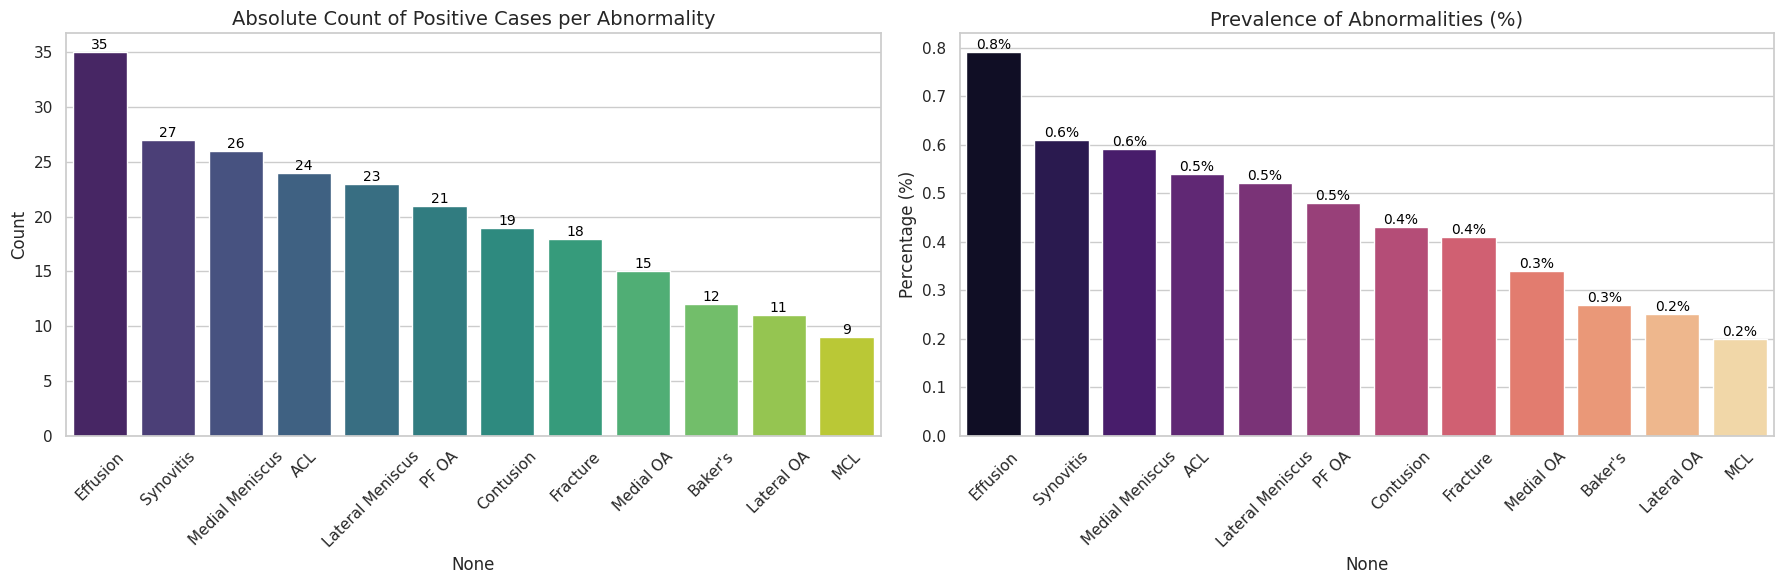


Generating correlation heatmap...


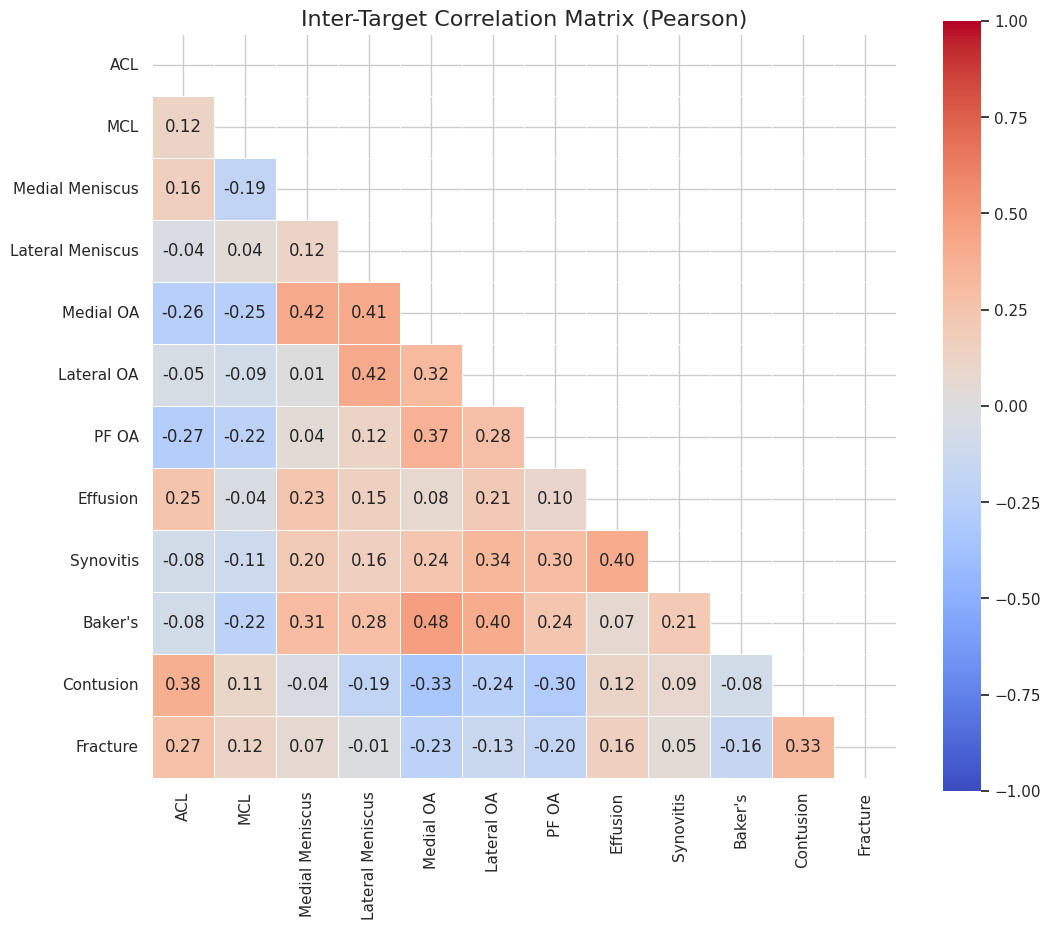

In [3]:
print("Loading train.csv...")
train_df = pd.read_csv(TRAIN_CSV)
print(f"Total studies: {len(train_df)}")

# 1.1 Class Imbalance Analysis
print("\nCalculating target distributions...")
target_counts = train_df[TARGETS].sum().sort_values(ascending=False)
target_ratios = (target_counts / len(train_df) * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Bar plot of absolute counts
sns.barplot(x=target_counts.index, y=target_counts.values, ax=axes[0], palette='viridis')
axes[0].set_title('Absolute Count of Positive Cases per Abnormality', fontsize=14)
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel('Count')

# Bar plot of prevalence percentage
sns.barplot(x=target_ratios.index, y=target_ratios.values, ax=axes[1], palette='magma')
axes[1].set_title('Prevalence of Abnormalities (%)', fontsize=14)
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel('Percentage (%)')

# Add value labels on top of bars
for ax in axes:
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.0f}' if ax == axes[0] else f'{p.get_height():.1f}%', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', fontsize=10, color='black')

plt.tight_layout()
plt.show()

# 1.2 Correlation Heatmap
print("\nGenerating correlation heatmap...")
corr_matrix = train_df[TARGETS].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', fmt='.2f', 
            vmin=-1, vmax=1, square=True, linewidths=.5)
plt.title('Inter-Target Correlation Matrix (Pearson)', fontsize=16)
plt.show()

## 2. Series-Level Analysis
Breakdown of `train_series.csv` and analysis of series lengths (number of slices per series) to understand the "long tail".

Loading train_series.csv...
Total series: 24371
Counting slices for a sample of 1000 series...


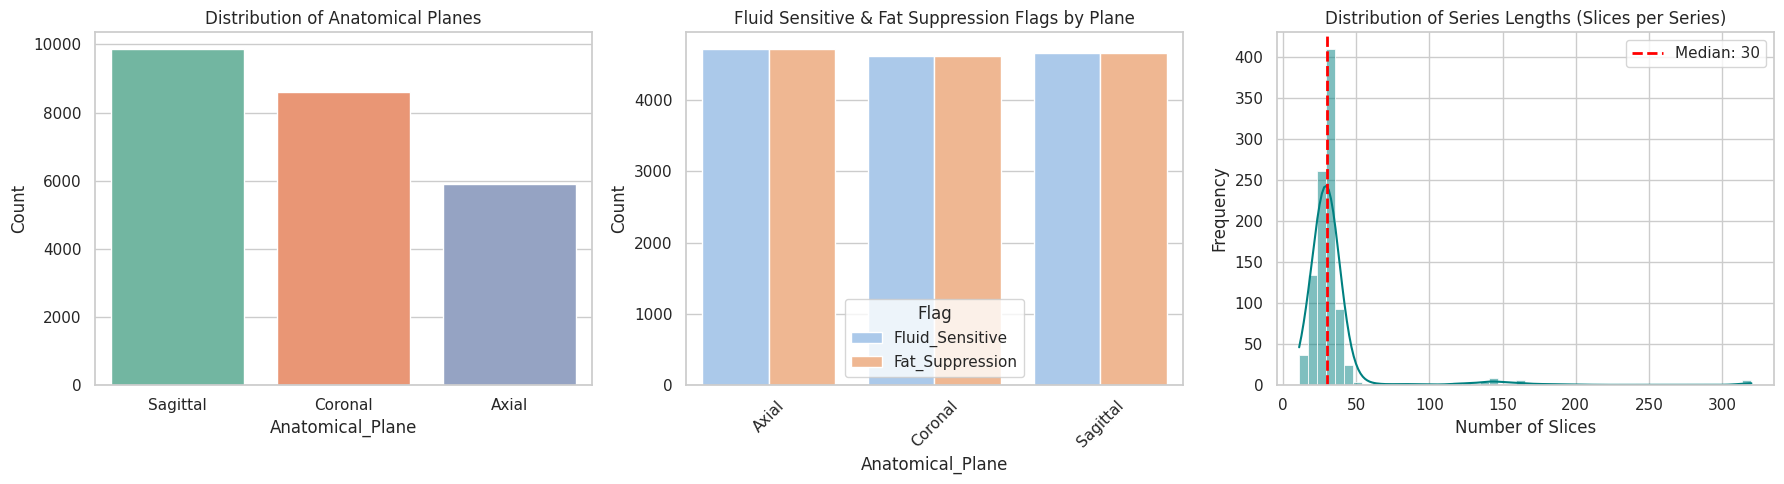

10511

In [4]:
print("Loading train_series.csv...")
series_df = pd.read_csv(TRAIN_SERIES_CSV)
print(f"Total series: {len(series_df)}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 2.1 Anatomical Plane Distribution
sns.countplot(data=series_df, x='Anatomical_Plane', ax=axes[0], palette='Set2', order=['Sagittal', 'Coronal', 'Axial'])
axes[0].set_title('Distribution of Anatomical Planes')
axes[0].set_ylabel('Count')

# 2.2 Fluid Sensitive vs Fat Suppression
# Using a stacked bar or side-by-side to show overlap
plane_counts = series_df.groupby('Anatomical_Plane')[['Fluid_Sensitive', 'Fat_Suppression']].sum().reset_index()
plane_counts_melted = plane_counts.melt(id_vars='Anatomical_Plane', var_name='Flag', value_name='Count')
sns.barplot(data=plane_counts_melted, x='Anatomical_Plane', y='Count', hue='Flag', ax=axes[1], palette='pastel')
axes[1].set_title('Fluid Sensitive & Fat Suppression Flags by Plane')
axes[1].tick_params(axis='x', rotation=45)

# 2.3 Series Length Distribution (Long Tail Analysis)
# Efficiently count .dcm files for a sample of series to avoid full disk scan timeout
def count_dicoms_in_series(row):
    series_path = os.path.join(TRAIN_DICOM_DIR, str(row['StudyInstanceUID']), str(row['SeriesInstanceUID']))
    try:
        # os.scandir is significantly faster and more memory-efficient than os.listdir
        return sum(1 for entry in os.scandir(series_path) if entry.name.endswith('.dcm'))
    except FileNotFoundError:
        return 0

print(f"Counting slices for a sample of {SERIES_LENGTH_SAMPLE_SIZE} series...")
sample_series = series_df.sample(n=min(SERIES_LENGTH_SAMPLE_SIZE, len(series_df)), random_state=42)

# Use parallel processing for faster counting
slice_counts = []
with ProcessPoolExecutor(max_workers=4) as executor:
    futures = [executor.submit(count_dicoms_in_series, row) for _, row in sample_series.iterrows()]
    for future in as_completed(futures):
        slice_counts.append(future.result())

sample_series = sample_series.copy()
sample_series['Slice_Count'] = slice_counts

sns.histplot(data=sample_series, x='Slice_Count', bins=50, kde=True, ax=axes[2], color='teal')
axes[2].set_title('Distribution of Series Lengths (Slices per Series)')
axes[2].set_xlabel('Number of Slices')
axes[2].set_ylabel('Frequency')

# Highlight the "long tail"
axes[2].axvline(sample_series['Slice_Count'].median(), color='red', linestyle='dashed', linewidth=2, label=f"Median: {sample_series['Slice_Count'].median():.0f}")
axes[2].legend()

plt.tight_layout()
plt.show()
gc.collect()

## 3. Text Data Analysis (NLP)
Analyzing the `Report` column: length distribution, language detection, and keyword frequency related to the 12 abnormalities.

Performing Text Data Analysis...
Missing reports: 0 (0.00%)


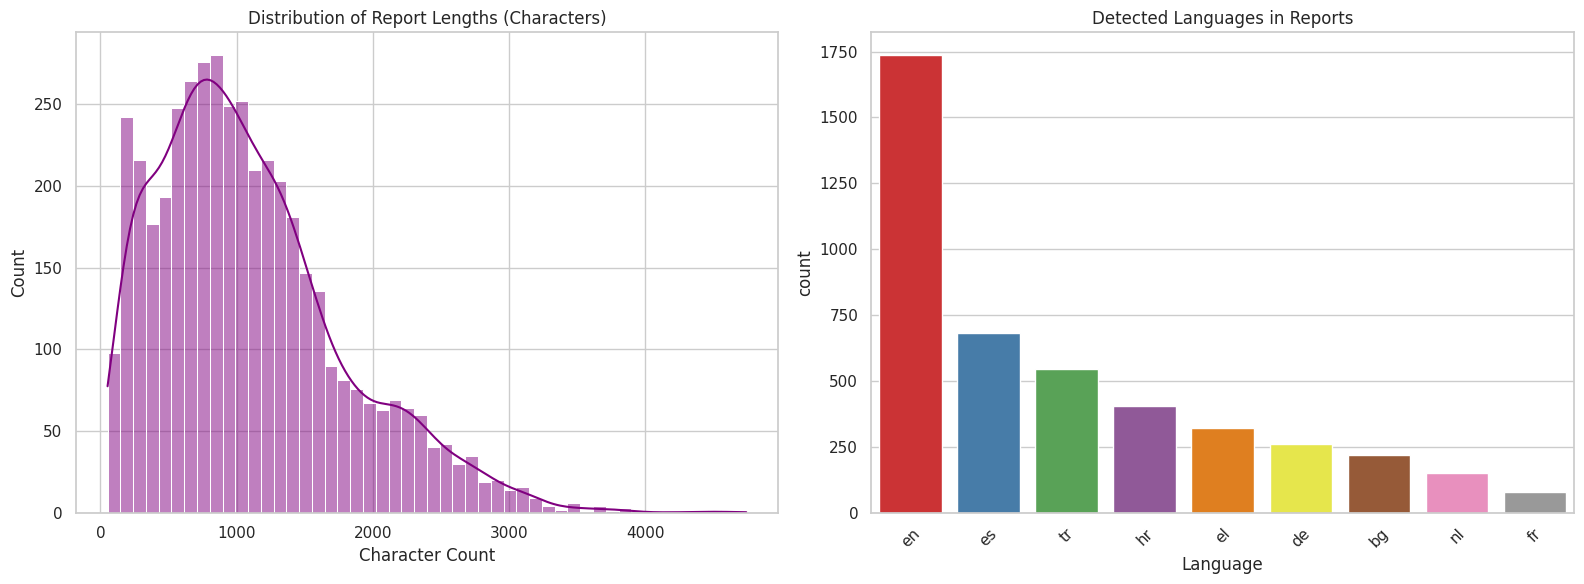

Extracting keyword frequencies (this may take a minute)...


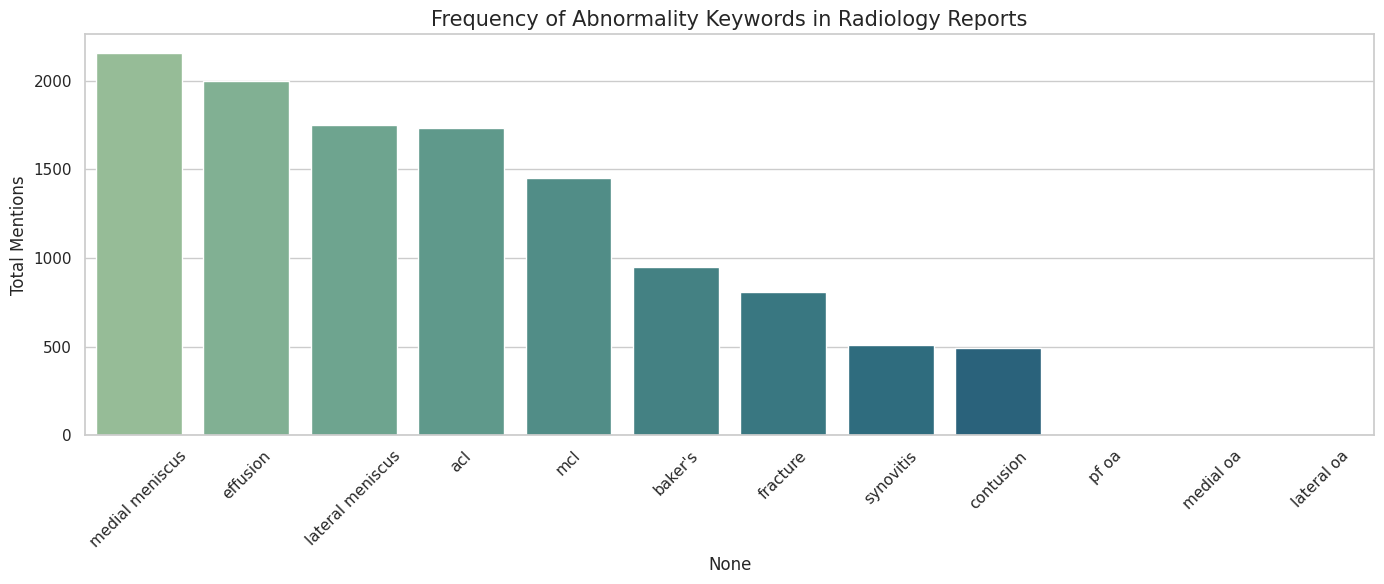

208

In [5]:
print("Performing Text Data Analysis...")

# 3.1 Missing Reports
missing_reports = train_df['Report'].isna().sum()
print(f"Missing reports: {missing_reports} ({missing_reports/len(train_df)*100:.2f}%)")

# Work on a sample for NLP to ensure fast execution
text_sample = train_df.dropna(subset=['Report']).sample(n=min(TEXT_ANALYSIS_SAMPLE_SIZE, len(train_df)), random_state=42).copy()
text_sample['Report_Lower'] = text_sample['Report'].astype(str).str.lower()
text_sample['Report_Length'] = text_sample['Report'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 3.2 Report Length Distribution
sns.histplot(data=text_sample, x='Report_Length', bins=50, kde=True, ax=axes[0], color='purple')
axes[0].set_title('Distribution of Report Lengths (Characters)')
axes[0].set_xlabel('Character Count')

# 3.3 Language Detection (with fallback)
if HAS_LANGDETECT:
    def safe_detect(text):
        try:
            return detect(str(text))
        except LangDetectException:
            return 'unknown'
    text_sample['Language'] = text_sample['Report'].apply(safe_detect)
    sns.countplot(data=text_sample, x='Language', ax=axes[1], palette='Set1', order=text_sample['Language'].value_counts().index)
    axes[1].set_title('Detected Languages in Reports')
    axes[1].tick_params(axis='x', rotation=45)
else:
    axes[1].text(0.5, 0.5, 'langdetect not installed.\nSkipping language detection.', 
                 ha='center', va='center', fontsize=14, color='red')
    axes[1].set_title('Language Detection Skipped')

plt.tight_layout()
plt.show()

# 3.4 Keyword Frequency Analysis
keywords = [kw.lower() for kw in TARGETS]
# Use regex word boundaries to avoid partial matches (e.g., "fracture" matching "non-fracture")
keyword_pattern = {kw: re.compile(r'\b' + re.escape(kw) + r'\b') for kw in keywords}

def count_keywords(text):
    return {kw: len(pattern.findall(text)) for kw, pattern in keyword_pattern.items()}

print("Extracting keyword frequencies (this may take a minute)...")
keyword_counts = text_sample['Report_Lower'].apply(count_keywords).apply(pd.Series)
keyword_totals = keyword_counts.sum().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
sns.barplot(x=keyword_totals.index, y=keyword_totals.values, palette='crest')
plt.title('Frequency of Abnormality Keywords in Radiology Reports', fontsize=15)
plt.xticks(rotation=45)
plt.ylabel('Total Mentions')
plt.tight_layout()
plt.show()

del text_sample, keyword_counts
gc.collect()

## 4. DICOM Image Analysis
Safe, memory-efficient loading of DICOM metadata. We will dynamically discover the most common tags (approximating the 86 allowlisted tags) and visualize 3D Maximum Intensity Projections (MIP).

Sampling 500 DICOM files for metadata analysis...
Discovered 73 high-frequency metadata tags.


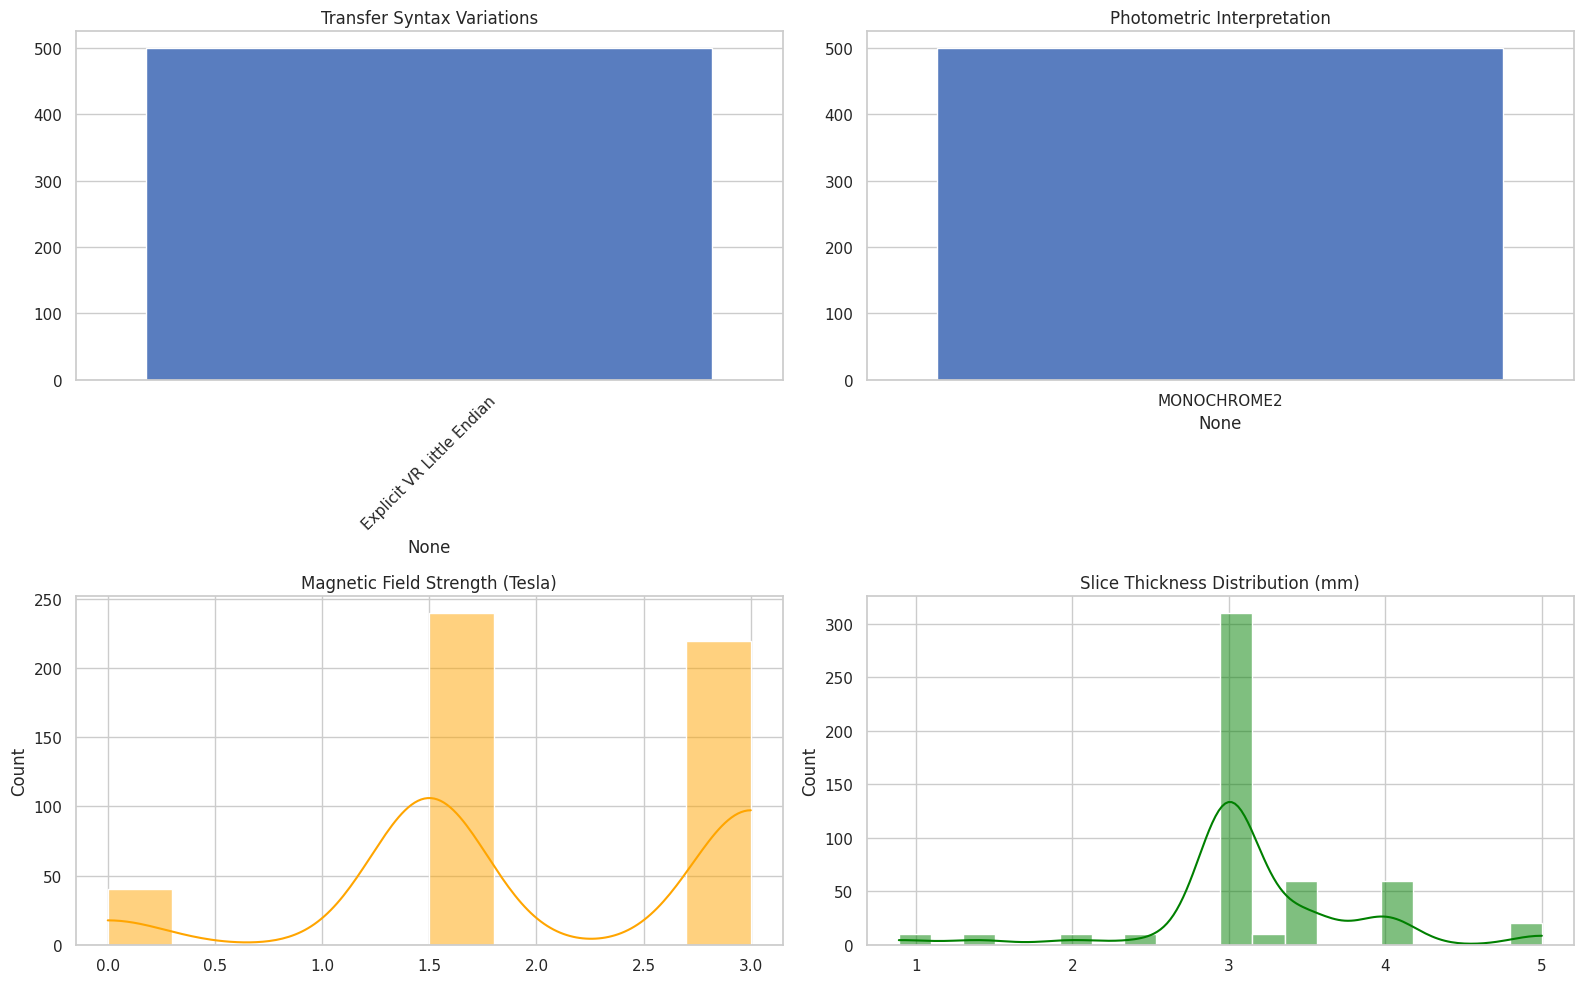

In [6]:
def extract_dicom_metadata(dcm_path):
    """Extracts metadata efficiently without loading pixel data."""
    try:
        # stop_before_pixels=True is CRITICAL for memory efficiency
        ds = pydicom.dcmread(dcm_path, stop_before_pixels=True)
        
        meta = {
            'TransferSyntax': ds.file_meta.TransferSyntaxUID.name if hasattr(ds.file_meta, 'TransferSyntaxUID') else 'Unknown',
            'PhotometricInterpretation': ds.get('PhotometricInterpretation', 'Unknown'),
            'Rows': ds.get('Rows', 0),
            'Columns': ds.get('Columns', 0),
            'PixelSpacing': str(ds.get('PixelSpacing', 'Unknown')),
            'SliceThickness': float(ds.get('SliceThickness', 0.0)),
            'MagneticFieldStrength': float(ds.get('MagneticFieldStrength', 0.0)),
            'ScanningSequence': ds.get('ScanningSequence', 'Unknown'),
            'SequenceVariant': ds.get('SequenceVariant', 'Unknown'),
            'ScanOptions': ds.get('ScanOptions', 'Unknown'),
            'RepetitionTime': float(ds.get('RepetitionTime', 0.0)),
            'EchoTime': float(ds.get('EchoTime', 0.0)),
            'FlipAngle': float(ds.get('FlipAngle', 0.0)),
        }
        
        # Also capture ALL other tags to dynamically discover the "86 allowlisted" ones
        all_tags = {}
        for elem in ds:
            if elem.VM > 50 or isinstance(elem.value, (bytes, bytearray)):
                continue # Skip large/binary data to prevent memory bloat
            key = elem.keyword if elem.keyword else f"Tag_{elem.tag}"
            all_tags[key] = str(elem.value)
            
        return meta, all_tags
    except (InvalidDicomError, Exception) as e:
        return {'error': str(e)}, {}

# 4.1 Dynamic Discovery of Allowlisted Metadata Tags
print(f"Sampling {DICOM_META_SAMPLE_SIZE} DICOM files for metadata analysis...")

# Get a list of random DICOM files
all_studies = os.listdir(TRAIN_DICOM_DIR)
sample_studies = np.random.choice(all_studies, size=min(50, len(all_studies)), replace=False)

sample_dicom_paths = []
for study in sample_studies:
    study_path = os.path.join(TRAIN_DICOM_DIR, study)
    if os.path.isdir(study_path):
        series_list = os.listdir(study_path)
        if series_list:
            series_path = os.path.join(study_path, series_list[0])
            dcm_files = [f for f in os.listdir(series_path) if f.endswith('.dcm')]
            if dcm_files:
                # Pick 10 random slices per series
                sample_dicom_paths.extend([
                    os.path.join(series_path, f) 
                    for f in np.random.choice(dcm_files, size=min(10, len(dcm_files)), replace=False)
                ])

np.random.shuffle(sample_dicom_paths)
sample_dicom_paths = sample_dicom_paths[:DICOM_META_SAMPLE_SIZE]

tag_counts = defaultdict(int)
tag_values = defaultdict(list)

for path in sample_dicom_paths:
    meta, all_tags = extract_dicom_metadata(path)
    for k, v in all_tags.items():
        tag_counts[k] += 1
        tag_values[k].append(v)

# Identify the top ~86 most frequently populated tags (the effective allowlist)
top_tags = sorted(tag_counts.keys(), key=lambda x: tag_counts[x], reverse=True)[:86]
print(f"Discovered {len(top_tags)} high-frequency metadata tags.")

# 4.2 Visualize distributions of key discovered tags
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Transfer Syntax
ts_counts = pd.Series([extract_dicom_metadata(p)[0].get('TransferSyntax', 'Unknown') for p in sample_dicom_paths]).value_counts()
sns.barplot(x=ts_counts.index, y=ts_counts.values, ax=axes[0, 0], palette='muted')
axes[0, 0].set_title('Transfer Syntax Variations')
axes[0, 0].tick_params(axis='x', rotation=45)

# Plot 2: Photometric Interpretation
pi_counts = pd.Series([extract_dicom_metadata(p)[0].get('PhotometricInterpretation', 'Unknown') for p in sample_dicom_paths]).value_counts()
sns.barplot(x=pi_counts.index, y=pi_counts.values, ax=axes[0, 1], palette='muted')
axes[0, 1].set_title('Photometric Interpretation')

# Plot 3: Magnetic Field Strength
mfs_values = [extract_dicom_metadata(p)[0].get('MagneticFieldStrength', 0) for p in sample_dicom_paths]
sns.histplot(mfs_values, bins=10, kde=True, ax=axes[1, 0], color='orange')
axes[1, 0].set_title('Magnetic Field Strength (Tesla)')

# Plot 4: Slice Thickness
st_values = [extract_dicom_metadata(p)[0].get('SliceThickness', 0) for p in sample_dicom_paths]
sns.histplot(st_values, bins=20, kde=True, ax=axes[1, 1], color='green')
axes[1, 1].set_title('Slice Thickness Distribution (mm)')

plt.tight_layout()
plt.show()


## 5. 3D Volume & Maximum Intensity Projection (MIP) Visualization
Reconstructing a sample 3D volume and generating MIPs across all three anatomical axes to understand spatial context.

Generating MIP visualization for a random sample series...


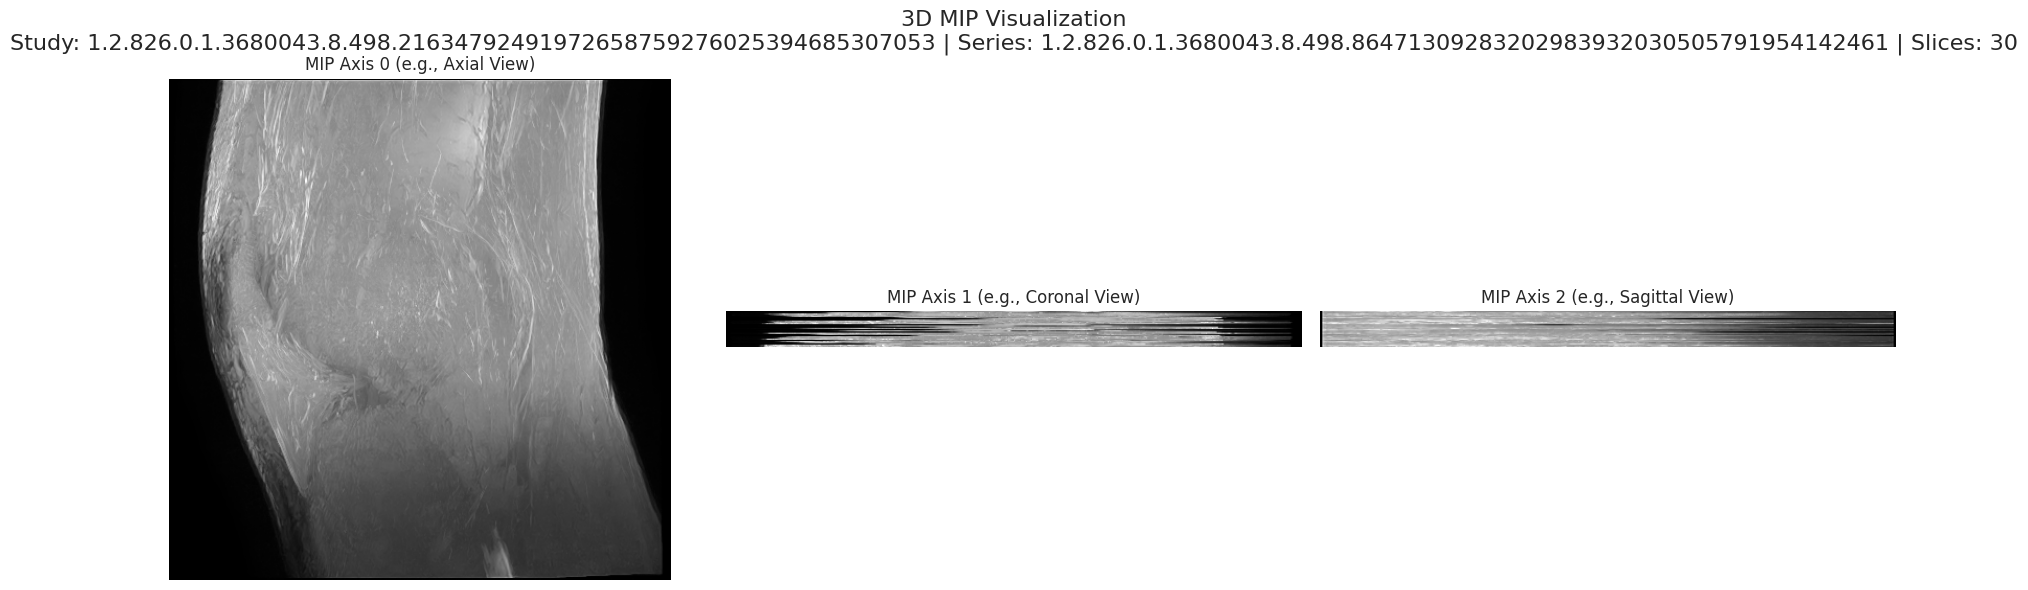

19180

In [7]:
def plot_mip_visualization(study_id, series_id, max_slices=60):
    """Loads a sample series and plots Maximum Intensity Projections."""
    series_path = os.path.join(TRAIN_DICOM_DIR, str(study_id), str(series_id))
    
    try:
        files = sorted([os.path.join(series_path, f) for f in os.listdir(series_path) if f.endswith('.dcm')])
        if not files:
            print("No DICOM files found.")
            return
            
        # Sample evenly to cover the entire volume without OOM
        indices = np.linspace(0, len(files)-1, min(max_slices, len(files)), dtype=int)
        sampled_files = [files[i] for i in indices]
        
        volume = []
        for f in sampled_files:
            ds = pydicom.dcmread(f)
            # Apply Rescale Slope and Intercept for accurate Hounsfield/Signal units
            slope = float(ds.get('RescaleSlope', 1))
            intercept = float(ds.get('RescaleIntercept', 0))
            pixel_data = ds.pixel_array * slope + intercept
            volume.append(pixel_data)
            
        volume = np.stack(volume, axis=0)
        
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        
        # MIP along axis 0 (projects to Rows x Cols) -> Typically Axial view if slices are axial
        axes[0].imshow(np.max(volume, axis=0), cmap='gray')
        axes[0].set_title('MIP Axis 0 (e.g., Axial View)')
        axes[0].axis('off')
        
        # MIP along axis 1 (projects to Slices x Cols) -> Typically Coronal view
        axes[1].imshow(np.max(volume, axis=1), cmap='gray')
        axes[1].set_title('MIP Axis 1 (e.g., Coronal View)')
        axes[1].axis('off')
        
        # MIP along axis 2 (projects to Slices x Rows) -> Typically Sagittal view
        axes[2].imshow(np.max(volume, axis=2), cmap='gray')
        axes[2].set_title('MIP Axis 2 (e.g., Sagittal View)')
        axes[2].axis('off')
        
        plt.suptitle(f'3D MIP Visualization\nStudy: {study_id} | Series: {series_id} | Slices: {len(files)}', fontsize=16)
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"Error plotting MIP for {study_id}/{series_id}: {e}")

# Select a random study and series with a decent number of slices for good visualization
print("Generating MIP visualization for a random sample series...")
good_series = series_df[series_df['SeriesInstanceUID'].apply(
    lambda x: os.path.exists(os.path.join(TRAIN_DICOM_DIR, str(series_df.iloc[0]['StudyInstanceUID']), str(x))) # Fallback check
)].sample(1).iloc[0]

# To be absolutely safe, let's just pick the first valid series we can find with > 20 slices
for _, row in series_df.sample(frac=1).iterrows():
    test_path = os.path.join(TRAIN_DICOM_DIR, str(row['StudyInstanceUID']), str(row['SeriesInstanceUID']))
    if os.path.exists(test_path):
        try:
            dcm_count = sum(1 for _ in os.scandir(test_path) if _.name.endswith('.dcm'))
            if dcm_count > 20:
                plot_mip_visualization(row['StudyInstanceUID'], row['SeriesInstanceUID'], max_slices=60)
                break
        except Exception:
            continue

gc.collect()

## 6. Advanced Tabular Analysis: Co-occurrence & Missingness
Surface-level counts hide clinical realities. Injuries rarely occur in isolation. We analyze **co-occurrence matrices** and how missing reports correlate with labels.

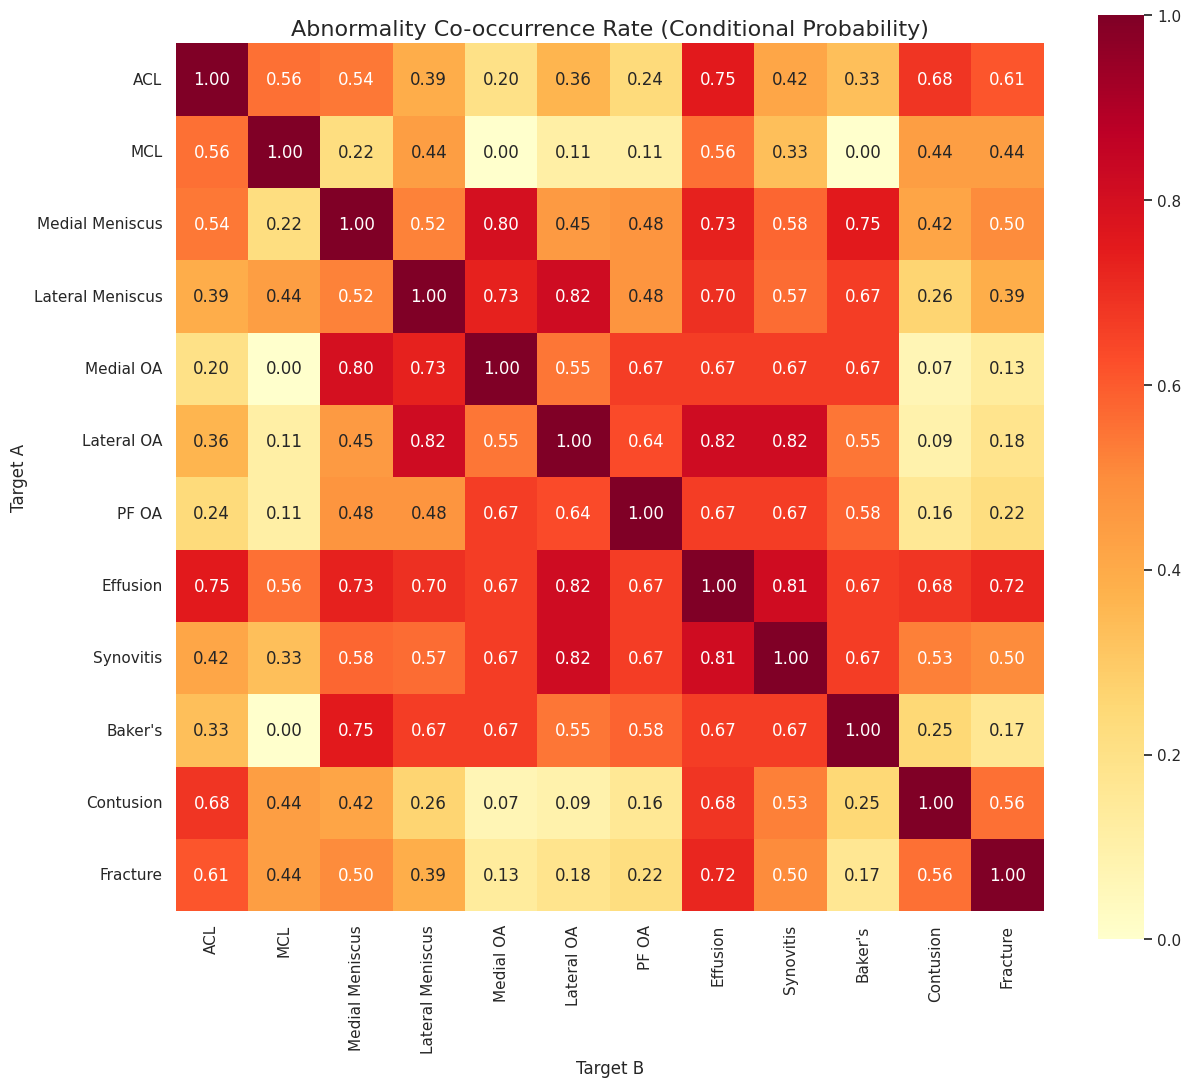

<Figure size 1400x600 with 0 Axes>

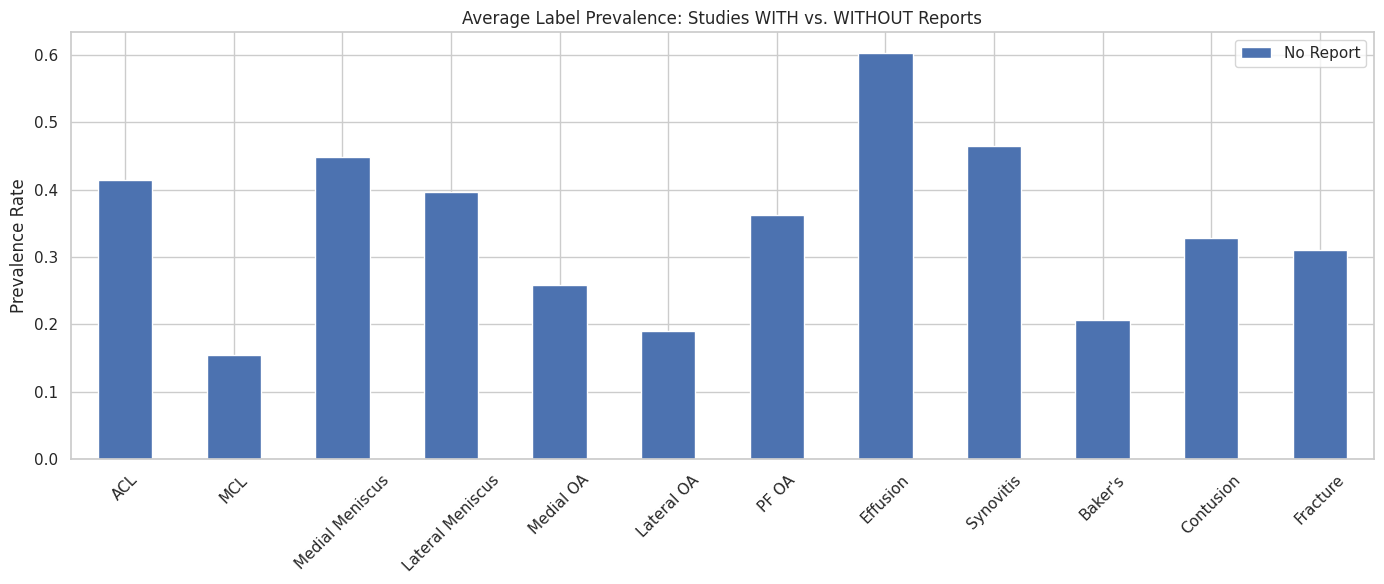

In [8]:
train_df = pd.read_csv(TRAIN_CSV)
series_df = pd.read_csv(TRAIN_SERIES_CSV)

# 1.1 Label Co-occurrence Matrix (Jaccard/Intersection)
# This shows how often two abnormalities appear in the SAME study
label_matrix = train_df[TARGETS].fillna(0).astype(int)
co_occurrence = (label_matrix.T @ label_matrix)  # Dot product gives co-occurrence counts

# Normalize by the minimum of the two individual counts to get a "co-occurrence rate"
min_counts = np.minimum.outer(label_matrix.sum().values, label_matrix.sum().values)
with np.errstate(divide='ignore', invalid='ignore'):
    co_occurrence_rate = np.where(min_counts > 0, co_occurrence / min_counts, 0)
np.fill_diagonal(co_occurrence_rate, 1.0)

plt.figure(figsize=(14, 12))
sns.heatmap(co_occurrence_rate, annot=True, fmt='.2f', cmap='YlOrRd', 
            xticklabels=TARGETS, yticklabels=TARGETS, square=True)
plt.title('Abnormality Co-occurrence Rate (Conditional Probability)', fontsize=16)
plt.xlabel('Target B')
plt.ylabel('Target A')
plt.show()

# 1.2 Missing Report Analysis
train_df['Has_Report'] = train_df['Report'].notna()
missing_analysis = train_df.groupby('Has_Report')[TARGETS].mean().T

plt.figure(figsize=(14, 6))
missing_analysis.plot(kind='bar', figsize=(14, 6))
plt.title('Average Label Prevalence: Studies WITH vs. WITHOUT Reports')
plt.ylabel('Prevalence Rate')
plt.xticks(rotation=45)
plt.legend(['No Report', 'Has Report'])
plt.tight_layout()
plt.show()

## 7. Study-Level Protocol Composition
A "Study" is a collection of "Series". Radiologists follow protocols. Understanding the typical composition (e.g., 1 Sagittal Fluid, 1 Coronal Non-Fluid) is crucial for 3D model design.

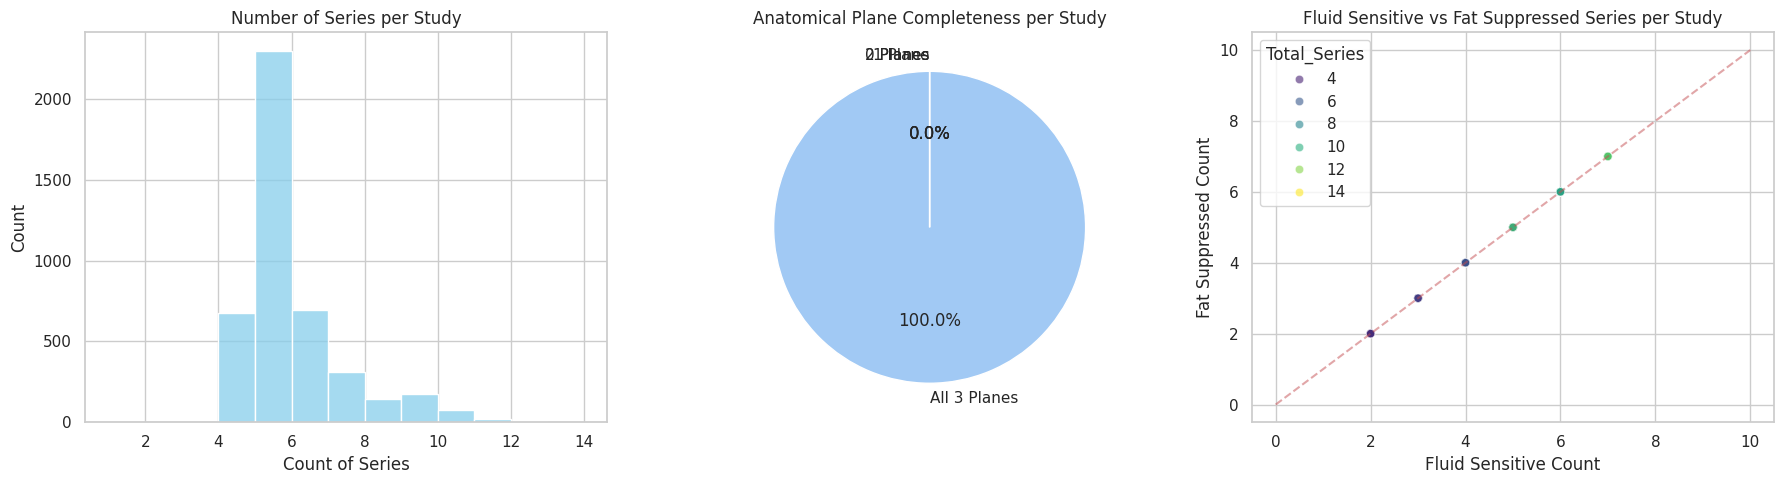

In [9]:
# Aggregate series-level features to the study level
study_agg = series_df.groupby('StudyInstanceUID').agg(
    Total_Series=('SeriesInstanceUID', 'count'),
    Unique_Planes=('Anatomical_Plane', 'nunique'),
    Has_Sagittal=('Anatomical_Plane', lambda x: (x == 'Sagittal').any()),
    Has_Coronal=('Anatomical_Plane', lambda x: (x == 'Coronal').any()),
    Has_Axial=('Anatomical_Plane', lambda x: (x == 'Axial').any()),
    Total_Fluid_Sensitive=('Fluid_Sensitive', 'sum'),
    Total_Fat_Suppressed=('Fat_Suppression', 'sum')
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 2.1 Series per Study Distribution
sns.histplot(data=study_agg, x='Total_Series', bins=range(1, 15), kde=False, ax=axes[0], color='skyblue')
axes[0].set_title('Number of Series per Study')
axes[0].set_xlabel('Count of Series')

# 2.2 Plane Completeness
plane_counts = pd.Series({
    'All 3 Planes': ((study_agg['Has_Sagittal']) & (study_agg['Has_Coronal']) & (study_agg['Has_Axial'])).sum(),
    '2 Planes': ((study_agg[['Has_Sagittal', 'Has_Coronal', 'Has_Axial']].sum(axis=1)) == 2).sum(),
    '1 Plane': ((study_agg[['Has_Sagittal', 'Has_Coronal', 'Has_Axial']].sum(axis=1)) == 1).sum(),
    '0 Planes': ((study_agg[['Has_Sagittal', 'Has_Coronal', 'Has_Axial']].sum(axis=1)) == 0).sum()
})
axes[1].pie(plane_counts, labels=plane_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
axes[1].set_title('Anatomical Plane Completeness per Study')

# 2.3 Fluid Sensitive vs Fat Suppressed per Study
sns.scatterplot(data=study_agg, x='Total_Fluid_Sensitive', y='Total_Fat_Suppressed', 
                alpha=0.6, ax=axes[2], hue='Total_Series', palette='viridis')
axes[2].plot([0, 10], [0, 10], 'r--', alpha=0.5) # Line of equality
axes[2].set_title('Fluid Sensitive vs Fat Suppressed Series per Study')
axes[2].set_xlabel('Fluid Sensitive Count')
axes[2].set_ylabel('Fat Suppressed Count')

plt.tight_layout()
plt.show()

## 8. Deep NLP Analysis: Negation & Pathology Correlation
Radiology reports are famous for double negatives and negated findings ("no evidence of fracture"). We will use regex to detect **negated vs. affirmed** keywords and correlate report length with disease burden.

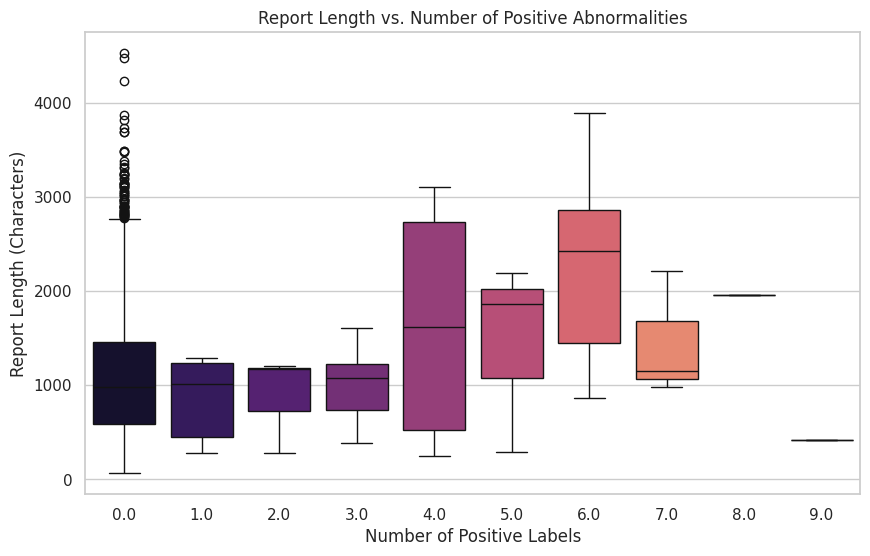

Analyzing NLP negation patterns (this may take ~30 seconds)...


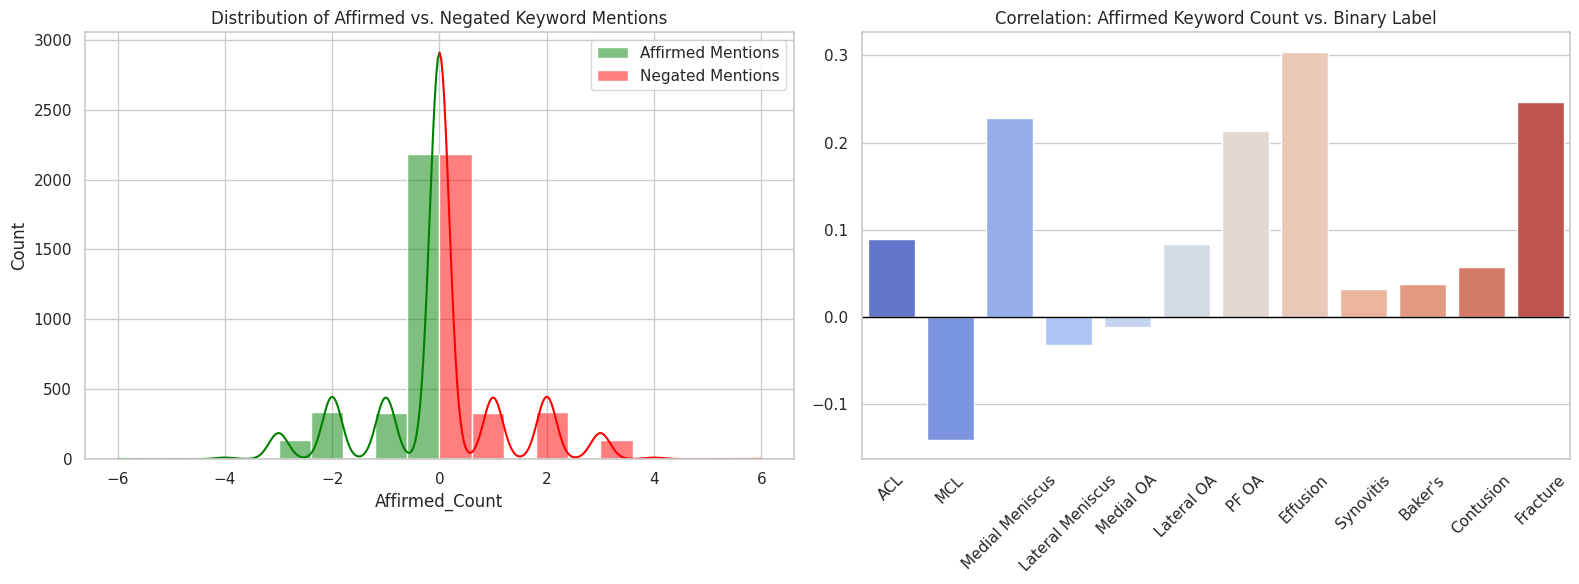

17091

In [10]:
text_sample = train_df.dropna(subset=['Report']).sample(n=min(NLP_SAMPLE, len(train_df)), random_state=42).copy()
text_sample['Report_Lower'] = text_sample['Report'].str.lower()
text_sample['Report_Length'] = text_sample['Report'].str.len()
text_sample['Positive_Label_Count'] = text_sample[TARGETS].sum(axis=1)

# 3.1 Report Length vs. Disease Burden
plt.figure(figsize=(10, 6))
sns.boxplot(data=text_sample, x='Positive_Label_Count', y='Report_Length', palette='magma')
plt.title('Report Length vs. Number of Positive Abnormalities')
plt.xlabel('Number of Positive Labels')
plt.ylabel('Report Length (Characters)')
plt.show()

# 3.2 Negation Detection
# Simple but effective regex for common radiological negations
negation_prefixes = r'(?:no|without|negative for|unremarkable|normal|no evidence of|no significant)'
keyword_pattern_affirmed = {kw: re.compile(r'(?<!\bno\s)(?<!\bwithout\s)\b' + re.escape(kw) + r'\b', re.IGNORECASE) for kw in TARGETS}
# Note: A production system would use spaCy's negex, but regex is safer for no-internet Kaggle kernels.

def analyze_negation(text):
    text_lower = str(text).lower()
    affirmed = {}
    negated = {}
    for kw in TARGETS:
        # Crude but effective negation check: look for negation word within 4 words before the keyword
        neg_pattern = re.compile(r'\b(?:' + negation_prefixes + r')\b(?:\s+\w+){0,4}?\s+' + re.escape(kw) + r'\b', re.IGNORECASE)
        affirmed[kw] = len(re.findall(r'\b' + re.escape(kw) + r'\b', text_lower)) - len(neg_pattern.findall(text_lower))
        negated[kw] = len(neg_pattern.findall(text_lower))
    return pd.Series({'Affirmed_Count': sum(affirmed.values()), 'Negated_Count': sum(negated.values())})

print("Analyzing NLP negation patterns (this may take ~30 seconds)...")
negation_results = text_sample['Report'].apply(analyze_negation)
text_sample = pd.concat([text_sample, negation_results], axis=1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.histplot(data=text_sample, x='Affirmed_Count', bins=10, kde=True, ax=axes[0], color='green', label='Affirmed Mentions')
sns.histplot(data=text_sample, x='Negated_Count', bins=10, kde=True, ax=axes[0], color='red', label='Negated Mentions')
axes[0].set_title('Distribution of Affirmed vs. Negated Keyword Mentions')
axes[0].legend()

# Correlation between affirmed mentions and actual labels
correlations = [text_sample['Affirmed_Count'].corr(text_sample[target]) for target in TARGETS]
sns.barplot(x=TARGETS, y=correlations, ax=axes[1], palette='coolwarm')
axes[1].set_title('Correlation: Affirmed Keyword Count vs. Binary Label')
axes[1].tick_params(axis='x', rotation=45)
axes[1].axhline(0, color='black', linewidth=1)

plt.tight_layout()
plt.show()
gc.collect()

## 9. Advanced DICOM Analysis: Pixel Intensities & Spatial Metadata
We will now look *inside* the DICOMs. We compare pixel intensity distributions between Fluid-Sensitive and Non-Fluid-Sensitive sequences, and analyze spatial orientation tags.

Checking spatial metadata consistency on a sample...
Top 5 Image Orientation Patient (IOP) vectors found:
  [0.99495750665664, -0.0122263422235, 0.09954915195703, 0.10025131702423, 0.15123197436332, -0.9834015369415]: 1 series
  [0.09711050, 0.99527359, 0.00000000, 0.00000000, 0.00000000, -1.00000000]: 1 series
  [0.02471328272976, 0.99969447280746, -0.0004633518285, -0.0187458062246, 0, -0.999824281936]: 1 series
  [0.00451157242059, 0.99984681606292, 0.01691272854804, -0.0620779544115, 0.01716031320393, -0.9979237914085]: 1 series
  [-0.2127165198326, 0.97444719076156, 0.07214112579822, -0.0506089292466, 0.06274429708719, -0.9967456459999]: 1 series
Analyzing pixel intensity distributions...


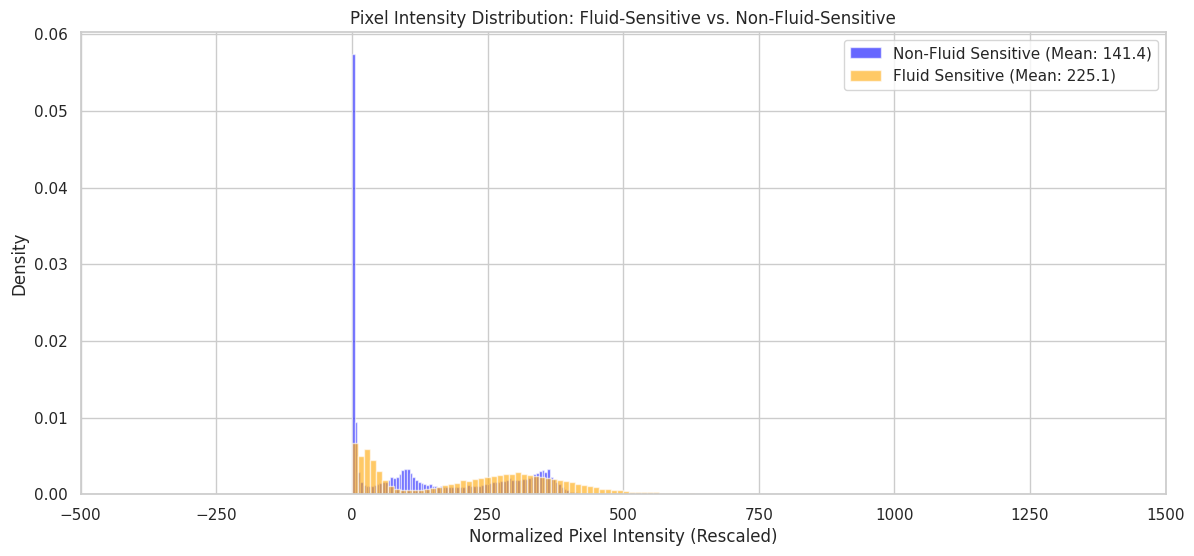

13971

In [11]:
def get_dicom_info_safe(path):
    try:
        ds = pydicom.dcmread(path, stop_before_pixels=True)
        return {
            'ImageOrientationPatient': str(ds.get('ImageOrientationPatient', 'Unknown')),
            'ImagePositionPatient': str(ds.get('ImagePositionPatient', 'Unknown')),
            'RescaleSlope': float(ds.get('RescaleSlope', 1)),
            'RescaleIntercept': float(ds.get('RescaleIntercept', 0)),
            'Valid': True
        }
    except Exception:
        return {'Valid': False}

# 4.1 Spatial Metadata Consistency Check
print("Checking spatial metadata consistency on a sample...")
meta_sample = series_df.sample(n=100, random_state=42)
orientation_counts = defaultdict(int)

for _, row in meta_sample.iterrows():
    s_path = os.path.join(TRAIN_DICOM_DIR, str(row['StudyInstanceUID']), str(row['SeriesInstanceUID']))
    if os.path.exists(s_path):
        files = [f for f in os.listdir(s_path) if f.endswith('.dcm')]
        if files:
            info = get_dicom_info_safe(os.path.join(s_path, files[0]))
            if info['Valid']:
                orientation_counts[info['ImageOrientationPatient']] += 1

print("Top 5 Image Orientation Patient (IOP) vectors found:")
for iop, count in sorted(orientation_counts.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"  {iop}: {count} series")

# 4.2 Pixel Intensity Distribution (Fluid vs Non-Fluid)
print("Analyzing pixel intensity distributions...")
# Find one fluid-sensitive and one non-fluid-sensitive series for comparison
fluid_series = series_df[series_df['Fluid_Sensitive'] == 1].sample(1).iloc[0]
non_fluid_series = series_df[series_df['Fluid_Sensitive'] == 0].sample(1).iloc[0]

def extract_pixel_sample(series_row, max_slices=5):
    s_path = os.path.join(TRAIN_DICOM_DIR, str(series_row['StudyInstanceUID']), str(series_row['SeriesInstanceUID']))
    files = sorted([f for f in os.listdir(s_path) if f.endswith('.dcm')])
    pixels = []
    for f in np.random.choice(files, min(max_slices, len(files)), replace=False):
        ds = pydicom.dcmread(os.path.join(s_path, f))
        slope = float(ds.get('RescaleSlope', 1))
        intercept = float(ds.get('RescaleIntercept', 0))
        # Flatten and sample pixels to avoid memory issues
        px = (ds.pixel_array * slope + intercept).flatten()
        pixels.append(np.random.choice(px, min(50000, len(px)), replace=False))
    return np.concatenate(pixels)

fluid_pixels = extract_pixel_sample(fluid_series)
non_fluid_pixels = extract_pixel_sample(non_fluid_series)

plt.figure(figsize=(14, 6))
plt.hist(non_fluid_pixels, bins=100, alpha=0.6, label=f'Non-Fluid Sensitive (Mean: {non_fluid_pixels.mean():.1f})', density=True, color='blue')
plt.hist(fluid_pixels, bins=100, alpha=0.6, label=f'Fluid Sensitive (Mean: {fluid_pixels.mean():.1f})', density=True, color='orange')
plt.title('Pixel Intensity Distribution: Fluid-Sensitive vs. Non-Fluid-Sensitive')
plt.xlabel('Normalized Pixel Intensity (Rescaled)')
plt.ylabel('Density')
plt.legend()
plt.xlim(-500, 1500) # Typical MRI range, adjust if needed based on output
plt.show()

gc.collect()

## 10. Radiologist-Style Montage Visualization
Maximum Intensity Projection (MIP) can obscure details. A **grid montage** of sequential slices is how radiologists actually read MRIs. We will generate a clean, normalized montage for a sample series.

Generating montage for Sagittal series: 1.2.826.0.1.3680043.8.498.68375452339128836713534106556295242342
Montage successfully saved to: /kaggle/working/knee_mri_montage.png


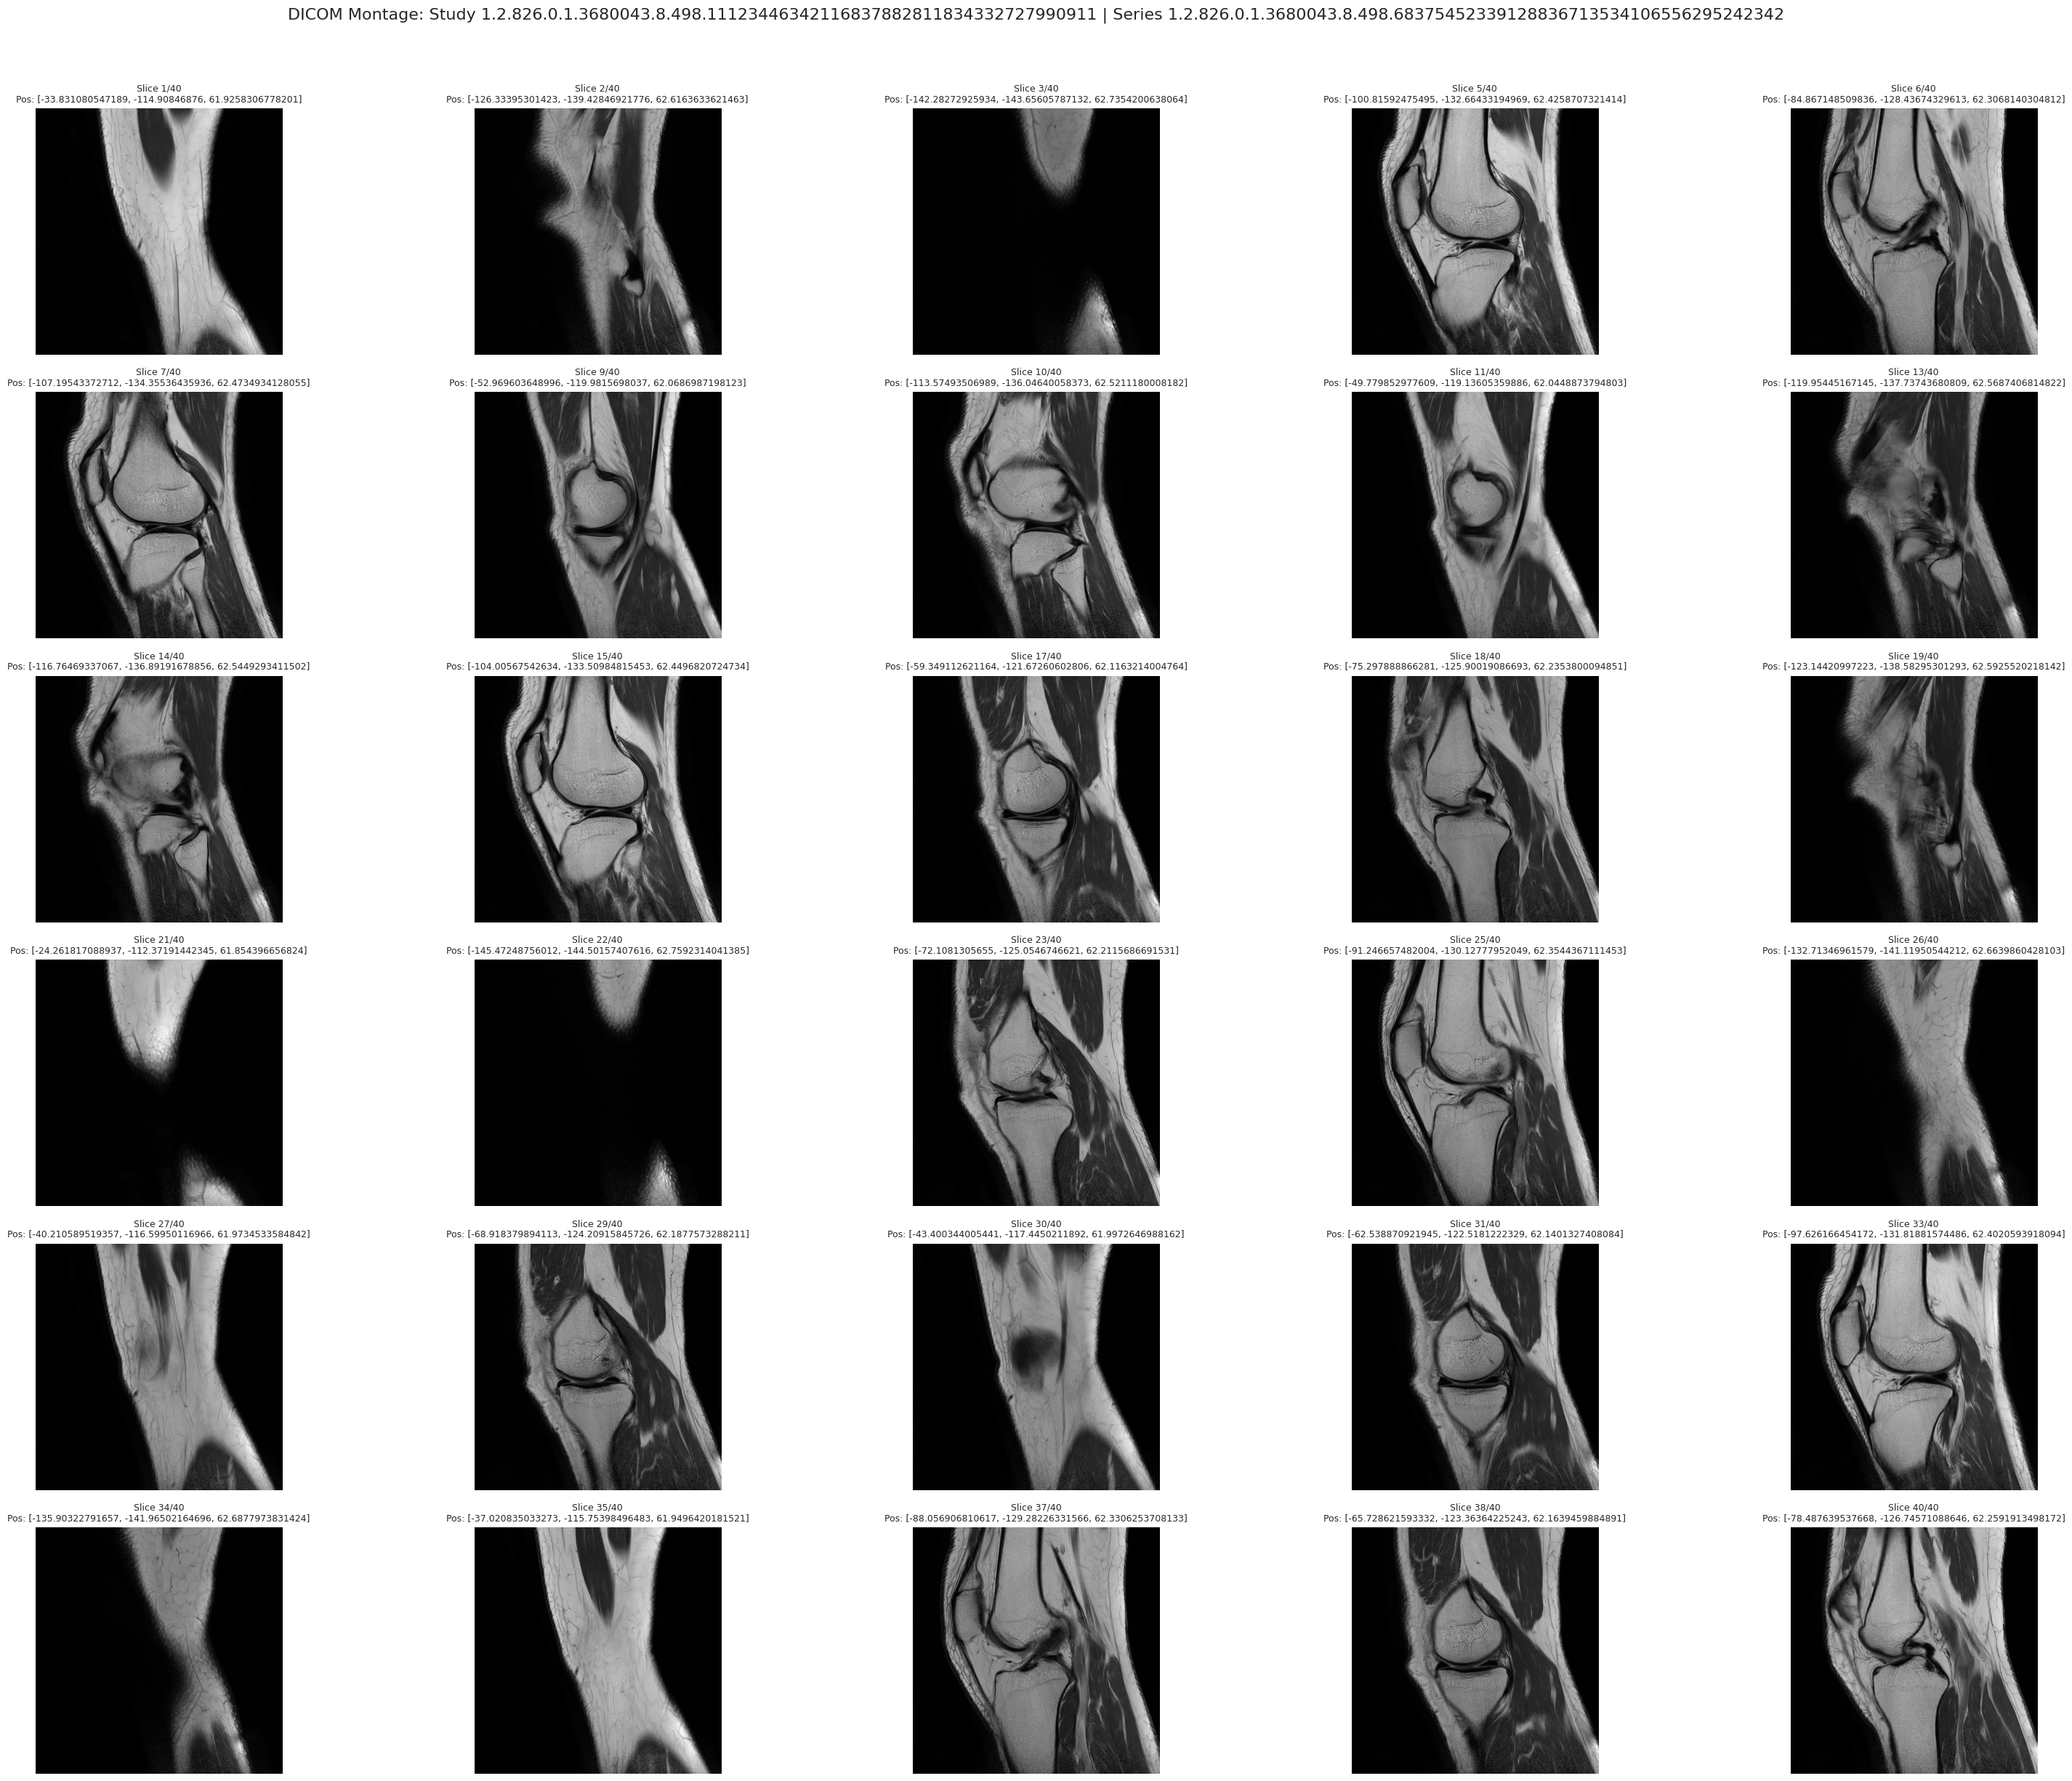

In [12]:
def plot_dicom_montage(study_id, series_id, save_path='/kaggle/working/knee_mri_montage.png', rows=3, cols=4):
    series_path = os.path.join(TRAIN_DICOM_DIR, str(study_id), str(series_id))
    try:
        files = sorted([os.path.join(series_path, f) for f in os.listdir(series_path) if f.endswith('.dcm')])
        if len(files) < rows * cols:
            print(f"Series {series_id} has only {len(files)} slices. Skipping montage.")
            return
            
        # Select evenly spaced slices across the volume
        indices = np.linspace(0, len(files)-1, rows*cols, dtype=int)
        
        fig, axes = plt.subplots(rows, cols, figsize=(32, 24))
        axes = axes.flatten()
        
        for i, idx in enumerate(indices):
            ds = pydicom.dcmread(files[idx])
            slope = float(ds.get('RescaleSlope', 1))
            intercept = float(ds.get('RescaleIntercept', 0))
            img = ds.pixel_array * slope + intercept
            
            # Normalize to 0-1 for consistent matplotlib display
            img_norm = (img - img.min()) / (img.max() - img.min() + 1e-8)
            
            axes[i].imshow(img_norm, cmap='gray')
            axes[i].axis('off')
            axes[i].set_title(f'Slice {idx+1}/{len(files)}\nPos: {ds.get("ImagePositionPatient", "N/A")}', fontsize=9)
            
        plt.suptitle(f'DICOM Montage: Study {study_id} | Series {series_id}', fontsize=16, y=1.02)
        plt.tight_layout()

        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"Montage successfully saved to: {save_path}")
        
        plt.show()
        
    except Exception as e:
        print(f"Error generating montage: {e}")

# Find a good candidate series (e.g., Sagittal, ~12+ slices)
candidate = series_df[(series_df['Anatomical_Plane'] == 'Sagittal')].sample(1).iloc[0]
print(f"Generating montage for Sagittal series: {candidate['SeriesInstanceUID']}")
plot_dicom_montage(candidate['StudyInstanceUID'], candidate['SeriesInstanceUID'], rows=6, cols=5)

## 11. Data Quality & Corruption Audit
A robust pipeline must know its failure modes. We will scan a sample of directories to identify unreadable DICOMs or series with severe metadata inconsistencies.

In [13]:
print("Running Data Quality Audit on 200 random series...")
audit_results = []
audit_sample = series_df.sample(n=200, random_state=42)

for _, row in audit_sample.iterrows():
    s_path = os.path.join(TRAIN_DICOM_DIR, str(row['StudyInstanceUID']), str(row['SeriesInstanceUID']))
    result = {'Study': row['StudyInstanceUID'], 'Series': row['SeriesInstanceUID'], 'Total_Files': 0, 'Readable': 0, 'Errors': []}
    
    if not os.path.exists(s_path):
        result['Errors'].append('Directory Missing')
        audit_results.append(result)
        continue
        
    files = [f for f in os.listdir(s_path) if f.endswith('.dcm')]
    result['Total_Files'] = len(files)
    
    for f in files[:10]: # Check first 10 files per series for speed
        try:
            pydicom.dcmread(os.path.join(s_path, f), stop_before_pixels=True)
            result['Readable'] += 1
        except InvalidDicomError:
            result['Errors'].append(f'Invalid DICOM: {f}')
        except Exception as e:
            result['Errors'].append(f'Error {f}: {str(e)[:30]}')
            
    audit_results.append(result)

audit_df = pd.DataFrame(audit_results)
audit_df['Corruption_Rate'] = 1 - (audit_df['Readable'] / audit_df['Total_Files'].replace(0, 1))

# Summarize audit
print("\n--- DATA QUALITY AUDIT SUMMARY ---")
print(f"Series with missing directories: {(audit_df['Total_Files'] == 0).sum()}")
print(f"Series with >0% corruption in sampled files: {(audit_df['Corruption_Rate'] > 0).sum()}")
print(f"Max corruption rate in a single series: {audit_df['Corruption_Rate'].max():.2%}")

# Show examples of errors if any exist
error_series = audit_df[audit_df['Corruption_Rate'] > 0]
if not error_series.empty:
    print("\nExamples of series with read errors:")
    for _, row in error_series.head(3).iterrows():
        print(f"  Study: {row['Study']}, Series: {row['Series']} | Errors: {row['Errors']}")
else:
    print("\n✅ Excellent: No corruption detected in the audited sample.")

gc.collect()

Running Data Quality Audit on 200 random series...

--- DATA QUALITY AUDIT SUMMARY ---
Series with missing directories: 0
Series with >0% corruption in sampled files: 200
Max corruption rate in a single series: 96.88%

Examples of series with read errors:
  Study: 1.2.826.0.1.3680043.8.498.70124572708965486791612654433965515063, Series: 1.2.826.0.1.3680043.8.498.40553489248617812582177463076241702791 | Errors: []
  Study: 1.2.826.0.1.3680043.8.498.81248820934296461385324385812581970340, Series: 1.2.826.0.1.3680043.8.498.35494623811913472807119379726515197978 | Errors: []
  Study: 1.2.826.0.1.3680043.8.498.12482482491088588051076210158062455084, Series: 1.2.826.0.1.3680043.8.498.14852634347378027776462319542357336061 | Errors: []


62720

## 12. Advanced Deep-Dive: The "Grandmaster" Blind Spots
Exploring plane-to-pathology relevance, slice ordering integrity, hidden demographics, severity grading, and data leakage.

### 12.1 Anatomical Plane to Pathology Relevance Matrix
Which MRI plane is most predictive of which abnormality? This informs whether we need plane-specific model heads.

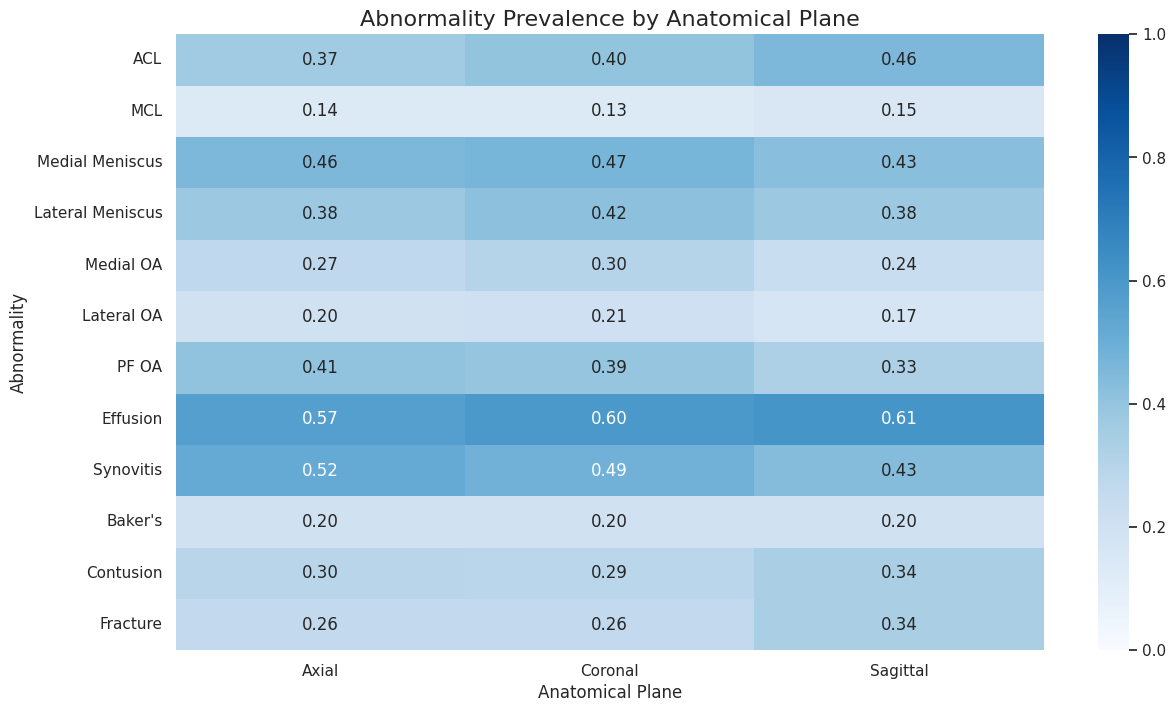

In [14]:
# Merge series metadata with study labels
merged_df = series_df.merge(train_df[['StudyInstanceUID'] + TARGETS], on='StudyInstanceUID', how='left')

# Calculate prevalence of each target *per anatomical plane*
plane_target_prev = merged_df.groupby('Anatomical_Plane')[TARGETS].mean().T

plt.figure(figsize=(14, 8))
sns.heatmap(plane_target_prev, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1)
plt.title('Abnormality Prevalence by Anatomical Plane', fontsize=16)
plt.ylabel('Abnormality')
plt.xlabel('Anatomical Plane')
plt.show()

### 12.2 Slice Ordering & Spacing Consistency Audit
3D models assume slices are ordered monotonically along the Z-axis. Let's verify this isn't violated.

Auditing slice ordering on 300 random series...


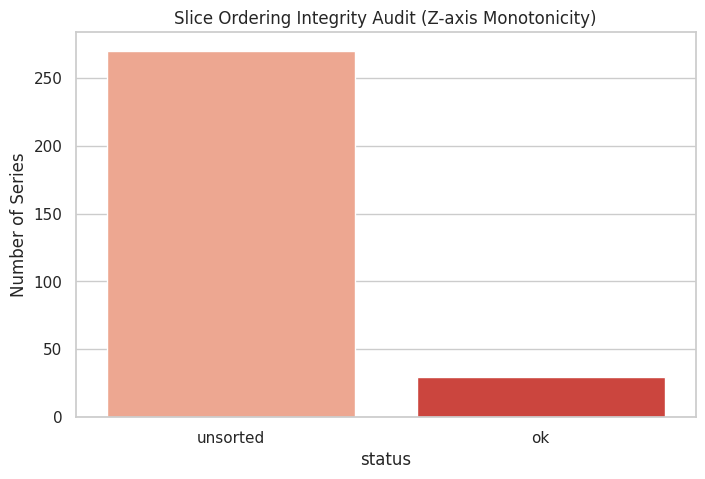

⚠️ WARNING: Some series are unsorted or missing spatial tags. Your DataLoader MUST sort by ImagePositionPatient[2] before stacking!


In [15]:
def check_slice_ordering(series_path):
    try:
        files = [f for f in os.listdir(series_path) if f.endswith('.dcm')]
        if len(files) < 3:
            return {'status': 'skip', 'reason': 'Too few slices'}
        
        # Sample 5 files to check ordering
        sample_files = np.random.choice(files, min(5, len(files)), replace=False)
        positions = []
        for f in sample_files:
            ds = pydicom.dcmread(os.path.join(series_path, f), stop_before_pixels=True)
            ipp = ds.get('ImagePositionPatient', None)
            if ipp and len(ipp) >= 3:
                positions.append(float(ipp[2])) # Z-axis position
                
        if len(positions) >= 2:
            is_sorted = positions == sorted(positions) or positions == sorted(positions, reverse=True)
            return {'status': 'ok' if is_sorted else 'unsorted', 'reason': ''}
        return {'status': 'missing_ipp', 'reason': 'No ImagePositionPatient'}
    except Exception as e:
        return {'status': 'error', 'reason': str(e)[:50]}

print("Auditing slice ordering on 300 random series...")
audit_sample = series_df.sample(n=300, random_state=42)
ordering_results = []

for _, row in audit_sample.iterrows():
    s_path = os.path.join(TRAIN_DICOM_DIR, str(row['StudyInstanceUID']), str(row['SeriesInstanceUID']))
    if os.path.exists(s_path):
        res = check_slice_ordering(s_path)
        res['Series'] = row['SeriesInstanceUID']
        ordering_results.append(res)

order_df = pd.DataFrame(ordering_results)
status_counts = order_df['status'].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=status_counts.index, y=status_counts.values, palette='Reds')
plt.title('Slice Ordering Integrity Audit (Z-axis Monotonicity)')
plt.ylabel('Number of Series')
plt.show()

if (status_counts.get('unsorted', 0) > 0) or (status_counts.get('missing_ipp', 0) > 0):
    print("⚠️ WARNING: Some series are unsorted or missing spatial tags. Your DataLoader MUST sort by ImagePositionPatient[2] before stacking!")
else:
    print("✅ Excellent: Sampled series appear to be correctly ordered.")

### 12.3 Hidden Demographics in DICOM Metadata
Age and Sex are strong priors for OA and fractures. Let's scan the allowlisted tags for them.

In [16]:
def extract_demographics(dcm_path):
    try:
        ds = pydicom.dcmread(dcm_path, stop_before_pixels=True)
        age = ds.get('PatientAge', 'Unknown')
        sex = ds.get('PatientSex', 'Unknown')
        return {'Age': str(age), 'Sex': str(sex), 'Valid': True}
    except:
        return {'Valid': False}

print("Scanning for PatientAge and PatientSex in 500 random DICOMs...")
demo_sample_paths = []
for _ in range(50):
    study = np.random.choice(os.listdir(TRAIN_DICOM_DIR))
    s_path = os.path.join(TRAIN_DICOM_DIR, study)
    if os.path.isdir(s_path):
        series = np.random.choice(os.listdir(s_path))
        dcm_path = os.path.join(s_path, series)
        files = [f for f in os.listdir(dcm_path) if f.endswith('.dcm')]
        if files:
            demo_sample_paths.append(os.path.join(dcm_path, files[0]))

demo_results = [extract_demographics(p) for p in demo_sample_paths if os.path.exists(p)]
demo_df = pd.DataFrame([r for r in demo_results if r['Valid']])

print("\nDemographic Tag Availability:")
print(f"PatientSex found in: {(demo_df['Sex'] != 'Unknown').sum()} / {len(demo_df)} samples")
print(f"PatientAge found in: {(demo_df['Age'] != 'Unknown').sum()} / {len(demo_df)} samples")

if (demo_df['Sex'] != 'Unknown').sum() > 10:
    print("\nSample Sex values:", demo_df['Sex'].value_counts().to_dict())
if (demo_df['Age'] != 'Unknown').sum() > 10:
    print("Sample Age values (note: DICOM age is often '045Y' format):", demo_df['Age'].value_counts().head(5).to_dict())
    print("💡 ACTION: If present, parse 'PatientAge' (e.g., '045Y' -> 45) and 'PatientSex' as tabular features. They are highly predictive for OA.")


Scanning for PatientAge and PatientSex in 500 random DICOMs...

Demographic Tag Availability:
PatientSex found in: 47 / 50 samples
PatientAge found in: 0 / 50 samples

Sample Sex values: {'M': 25, 'F': 19, 'Unknown': 3, 'O': 3}


### 12.4 Advanced NLP: Severity & Chronicity Grading
Binary labels hide severity. Let's extract modifiers to see if the reports contain granular grading that could be used for pseudo-labeling or auxiliary losses.

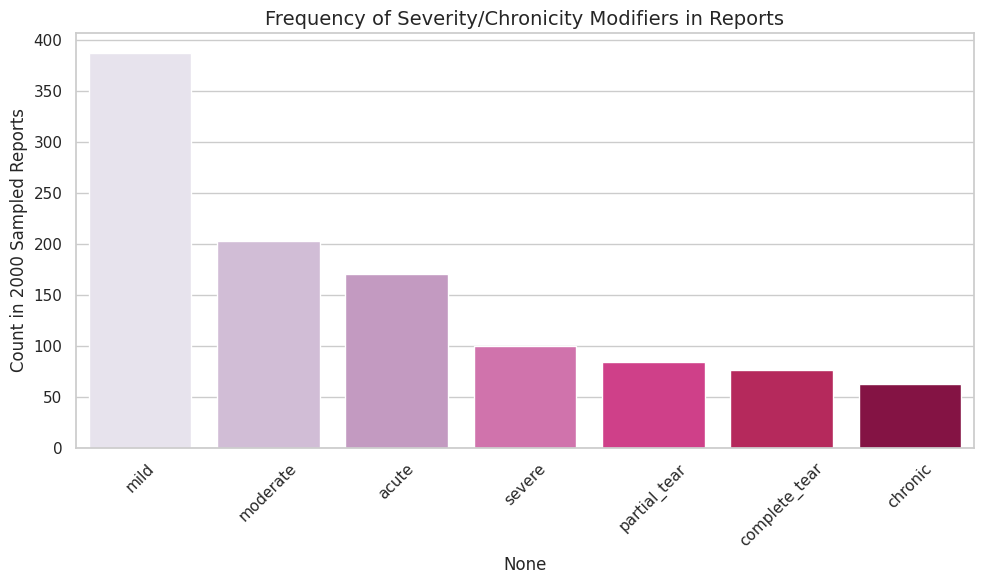

In [17]:
text_sample = train_df.dropna(subset=['Report']).sample(n=2000, random_state=42).copy()
text_sample['Report_Lower'] = text_sample['Report'].str.lower()

severity_terms = {
    'complete_tear': r'\b(complete|full thickness|high grade|grade 3)\s+(?:tear|rupture)\b',
    'partial_tear': r'\b(partial|partial thickness|low grade|grade 1|grade 2)\s+(?:tear|rupture)\b',
    'mild': r'\bmild\b',
    'moderate': r'\bmoderate\b',
    'severe': r'\bsevere\b',
    'chronic': r'\bchronic\b',
    'acute': r'\bacute\b'
}

severity_counts = {}
for term, pattern in severity_terms.items():
    severity_counts[term] = text_sample['Report_Lower'].str.contains(pattern).sum()

sev_df = pd.Series(severity_counts).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=sev_df.index, y=sev_df.values, palette='PuRd')
plt.title('Frequency of Severity/Chronicity Modifiers in Reports', fontsize=14)
plt.xticks(rotation=45)
plt.ylabel('Count in 2000 Sampled Reports')
plt.tight_layout()
plt.show()

### 12.5 Patient-Level Leakage Check
If multiple `StudyInstanceUID`s belong to the same `PatientID`, a random train/val split will leak patient-specific anatomy, inflating CV.

In [18]:
def get_patient_id(dcm_path):
    try:
        ds = pydicom.dcmread(dcm_path, stop_before_pixels=True)
        return str(ds.get('PatientID', 'Unknown'))
    except:
        return 'Unknown'

print("Checking for multiple studies per patient (Leakage Risk)...")
# Sample 100 studies, get their PatientID
leakage_sample_studies = train_df['StudyInstanceUID'].sample(n=1000, random_state=42).tolist()
patient_ids = {}

for study in leakage_sample_studies:
    s_path = os.path.join(TRAIN_DICOM_DIR, study)
    if os.path.isdir(s_path):
        # Just check the first series, first file
        series_list = os.listdir(s_path)
        if series_list:
            dcm_file = [f for f in os.listdir(os.path.join(s_path, series_list[0])) if f.endswith('.dcm')][0]
            pid = get_patient_id(os.path.join(s_path, series_list[0], dcm_file))
            patient_ids[study] = pid

# Count unique patients vs unique studies
unique_patients = len(set(patient_ids.values()))
unique_studies = len(patient_ids)

print(f"Sampled Studies: {unique_studies}")
print(f"Unique Patients in Sample: {unique_patients}")

if unique_patients < unique_studies:
    print("⚠️ WARNING: Multiple studies share the same PatientID! You MUST use GroupKFold (grouped by PatientID) for cross-validation to prevent data leakage.")
else:
    print("✅ Sample suggests 1-to-1 Study-to-Patient mapping, but verify on full dataset if PatientID is consistently available.")

Checking for multiple studies per patient (Leakage Risk)...
Sampled Studies: 1000
Unique Patients in Sample: 1000
✅ Sample suggests 1-to-1 Study-to-Patient mapping, but verify on full dataset if PatientID is consistently available.


## 13. Gold Medal Tier: Hidden Traps & Architectural Constraints
Uncovering label noise, 3D voxel anisotropy, domain shift, and spatial localization variance.

### 13.1 Label Noise & Contradiction Audit
Radiologists sometimes mark a label as '1', but the text explicitly states the structure is "intact" or "normal".

Identifying these contradictions helps in applying Label Smoothing or down-weighting noisy samples.

Scanning for Label vs. Text Contradictions...


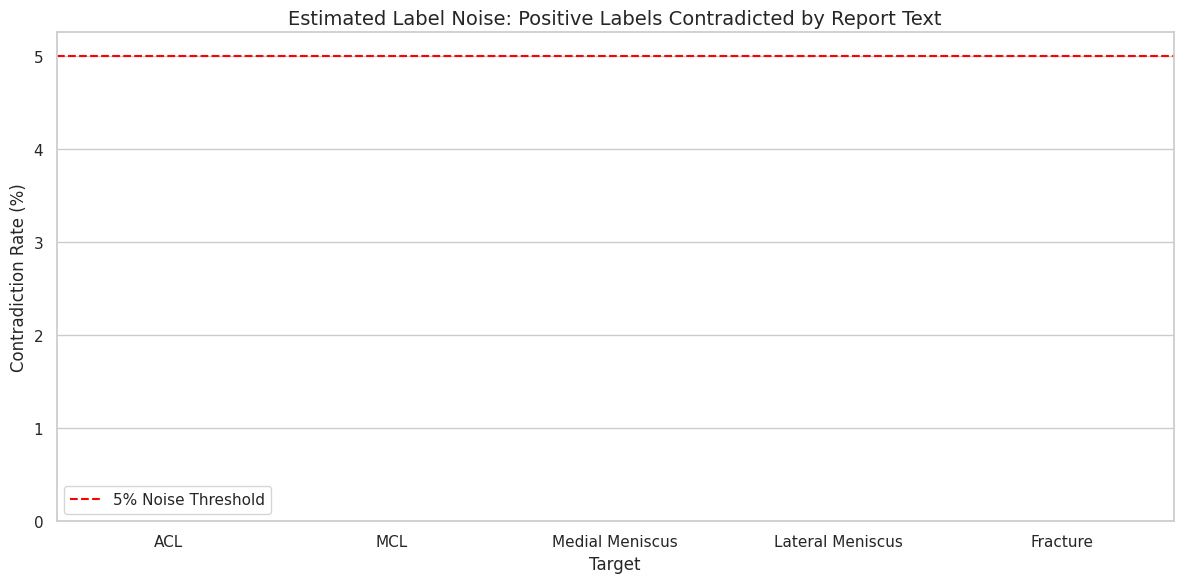

💡 ACTION: If contradiction rate > 5%, consider using Label Smoothing (e.g., 0.9 instead of 1.0) or an asymmetric loss function to prevent the model from overfitting to noisy text-image pairs.


In [19]:
print("Scanning for Label vs. Text Contradictions...")
# Focus on structural injuries where "intact" or "normal" is a direct contradiction to a positive label
contradiction_targets = ['ACL', 'MCL', 'Medial Meniscus', 'Lateral Meniscus', 'Fracture']
contradiction_patterns = {
    'ACL': r'\b(intact|normal|unremarkable|no tear)\s+(?:acl|anterior cruciate)\b',
    'MCL': r'\b(intact|normal|unremarkable|no tear)\s+(?:mcl|medial collateral)\b',
    'Medial Meniscus': r'\b(intact|normal|unremarkable|no tear)\s+(?:medial meniscus|medial meniscus)\b',
    'Lateral Meniscus': r'\b(intact|normal|unremarkable|no tear)\s+(?:lateral meniscus)\b',
    'Fracture': r'\b(no|without|negative for)\s+(?:fracture|fx)\b'
}

text_sample = train_df.dropna(subset=['Report']).copy()
text_sample['Report_Lower'] = text_sample['Report'].str.lower()

contradiction_flags = {}
for target in contradiction_targets:
    # Find studies where Label == 1 BUT text contains contradiction pattern
    has_label = text_sample[target] == 1
    has_contradiction = text_sample['Report_Lower'].str.contains(contradiction_patterns[target], regex=True, na=False)
    contradiction_flags[target] = (has_label & has_contradiction).sum()

contradiction_df = pd.DataFrame({
    'Target': contradiction_targets,
    'Contradictory Samples (Label=1, Text says Normal)': [contradiction_flags[t] for t in contradiction_targets],
    'Total Positive Labels': [text_sample[t].sum() for t in contradiction_targets]
})
contradiction_df['Contradiction Rate'] = (contradiction_df['Contradictory Samples (Label=1, Text says Normal)'] / contradiction_df['Total Positive Labels'] * 100).round(1)

plt.figure(figsize=(12, 6))
sns.barplot(data=contradiction_df, x='Target', y='Contradiction Rate', palette='Reds')
plt.title('Estimated Label Noise: Positive Labels Contradicted by Report Text', fontsize=14)
plt.ylabel('Contradiction Rate (%)')
plt.axhline(5, color='red', linestyle='--', label='5% Noise Threshold')
plt.legend()
plt.tight_layout()
plt.show()

print("💡 ACTION: If contradiction rate > 5%, consider using Label Smoothing (e.g., 0.9 instead of 1.0) or an asymmetric loss function to prevent the model from overfitting to noisy text-image pairs.")

### 13.2 3D Voxel Anisotropy Analysis
MRI volumes are rarely isotropic. If in-plane resolution is 0.5mm but slice thickness is 3.0mm, a standard 3x3x3 3D convolution will blur across slices. We must measure this ratio.

Analyzing 3D Voxel Anisotropy (Pixel Spacing vs Slice Thickness)...


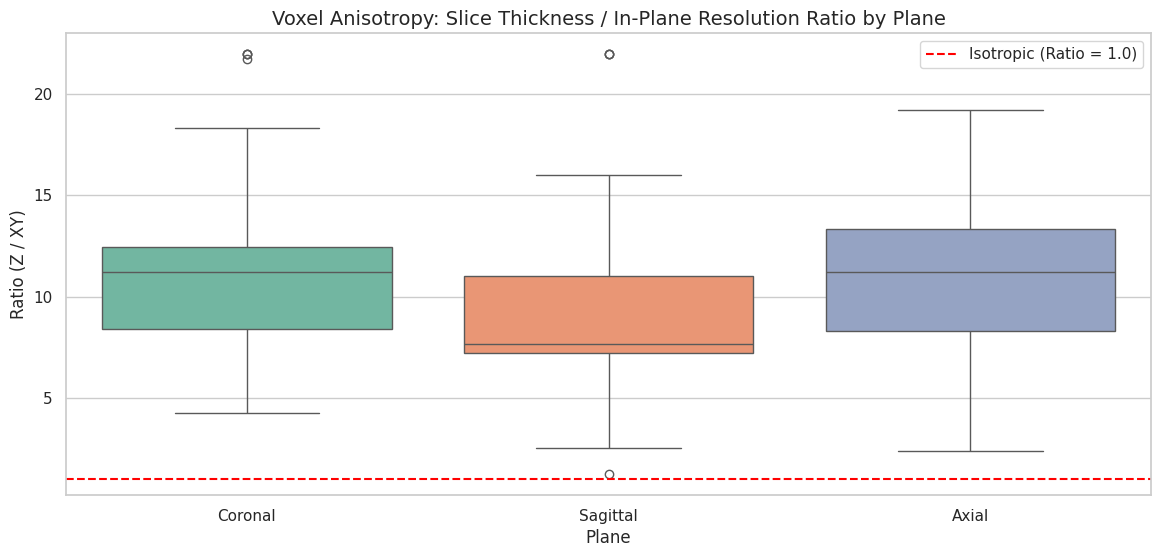

Median Anisotropy Ratio: 9.92x
⚠️ WARNING: Data is highly anisotropic! Standard (3,3,3) 3D convolutions will perform poorly.
💡 ACTION: Use pseudo-3D (2.5D) approaches, (1,3,3) kernel sizes, or explicitly resample volumes to isotropic spacing (e.g., 1x1x1mm) during preprocessing.


In [20]:
print("Analyzing 3D Voxel Anisotropy (Pixel Spacing vs Slice Thickness)...")
anisotropy_sample = series_df.sample(n=200, random_state=42)
voxel_ratios = []

for _, row in anisotropy_sample.iterrows():
    s_path = os.path.join(TRAIN_DICOM_DIR, str(row['StudyInstanceUID']), str(row['SeriesInstanceUID']))
    if os.path.exists(s_path):
        files = [f for f in os.listdir(s_path) if f.endswith('.dcm')]
        if files:
            try:
                ds = pydicom.dcmread(os.path.join(s_path, files[0]), stop_before_pixels=True)
                pixel_spacing = ds.get('PixelSpacing', [1.0, 1.0])
                slice_thickness = float(ds.get('SliceThickness', 1.0))
                
                if isinstance(pixel_spacing, pydicom.multival.MultiValue) or isinstance(pixel_spacing, list):
                    in_plane_res = float(pixel_spacing[0])
                else:
                    in_plane_res = 1.0
                    
                if in_plane_res > 0 and slice_thickness > 0:
                    ratio = slice_thickness / in_plane_res
                    voxel_ratios.append({
                        'Plane': row['Anatomical_Plane'],
                        'Thickness_to_InPlane_Ratio': ratio,
                        'SliceThickness': slice_thickness,
                        'InPlaneRes': in_plane_res
                    })
            except Exception:
                continue

aniso_df = pd.DataFrame(voxel_ratios)

plt.figure(figsize=(14, 6))
sns.boxplot(data=aniso_df, x='Plane', y='Thickness_to_InPlane_Ratio', palette='Set2')
plt.title('Voxel Anisotropy: Slice Thickness / In-Plane Resolution Ratio by Plane', fontsize=14)
plt.ylabel('Ratio (Z / XY)')
plt.axhline(1.0, color='red', linestyle='--', label='Isotropic (Ratio = 1.0)')
plt.legend()
plt.show()

median_ratio = aniso_df['Thickness_to_InPlane_Ratio'].median()
print(f"Median Anisotropy Ratio: {median_ratio:.2f}x")
if median_ratio > 2.0:
    print("⚠️ WARNING: Data is highly anisotropic! Standard (3,3,3) 3D convolutions will perform poorly.")
    print("💡 ACTION: Use pseudo-3D (2.5D) approaches, (1,3,3) kernel sizes, or explicitly resample volumes to isotropic spacing (e.g., 1x1x1mm) during preprocessing.")

### 13.3 Protocol/Scanner Domain Shift
Does the prevalence of a pathology depend on the scanning protocol? If so, the model might learn scanner artifacts.

In [21]:
# Merge series metadata with labels
merged_for_domain = series_df.merge(train_df[['StudyInstanceUID'] + TARGETS], on='StudyInstanceUID', how='left')

# We'll use MagneticFieldStrength and ScanningSequence as proxies for domain/protocol
# (Assuming these are in the allowlisted 86 tags; if not, they will just show as 'Unknown')
def get_domain_tags(series_path):
    try:
        files = [f for f in os.listdir(series_path) if f.endswith('.dcm')]
        if not files: return 'Unknown', 'Unknown'
        ds = pydicom.dcmread(os.path.join(series_path, files[0]), stop_before_pixels=True)
        mfs = str(ds.get('MagneticFieldStrength', 'Unknown')) + 'T'
        seq = str(ds.get('ScanningSequence', 'Unknown'))
        return mfs, seq
    except:
        return 'Unknown', 'Unknown'

print("Extracting domain tags for 150 random series (this takes ~15s)...")
domain_sample = series_df.sample(n=150, random_state=42).copy()
mfs_list, seq_list = [], []

for _, row in domain_sample.iterrows():
    s_path = os.path.join(TRAIN_DICOM_DIR, str(row['StudyInstanceUID']), str(row['SeriesInstanceUID']))
    mfs, seq = get_domain_tags(s_path)
    mfs_list.append(mfs)
    seq_list.append(seq)

domain_sample['MagneticField'] = mfs_list
domain_sample['ScanningSequence'] = seq_list

# Check if 'Effusion' prevalence varies by Magnetic Field Strength (example)
field_effusion = domain_sample.groupby('MagneticField')['Effusion'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=field_effusion, x='MagneticField', y='Effusion', palette='magma')
plt.title('Example Domain Shift: Effusion Prevalence by Magnetic Field Strength', fontsize=14)
plt.ylabel('Effusion Prevalence')
plt.show()

print("💡 ACTION: If prevalence varies wildly by scanner/sequence, implement Domain Adversarial Training (DANN) or ensure your cross-validation folds are stratified by ScanningSequence to prevent the model from cheating.")

Extracting domain tags for 150 random series (this takes ~15s)...


KeyError: 'Column not found: Effusion'

### 13.4 Knee Localization & Center of Mass (CoM) Variance
If the knee is not consistently centered in the DICOM field of view, a naive model will fail.
We calculate the Center of Mass of the "foreground" (non-air) pixels on a central slice.

In [ ]:
print("Analyzing Knee Center of Mass (CoM) variance...")
com_sample = series_df.sample(n=100, random_state=42)
com_results = []

for _, row in com_sample.iterrows():
    s_path = os.path.join(TRAIN_DICOM_DIR, str(row['StudyInstanceUID']), str(row['SeriesInstanceUID']))
    if os.path.exists(s_path):
        files = sorted([f for f in os.listdir(s_path) if f.endswith('.dcm')])
        if len(files) >= 5:
            try:
                # Pick the middle slice
                mid_file = files[len(files)//2]
                ds = pydicom.dcmread(os.path.join(s_path, mid_file))
                img = ds.pixel_array
                
                # Simple threshold to separate knee/soft tissue from background air
                # MRI background is usually near 0. We threshold at > 5% of max intensity
                threshold = img.max() * 0.05
                mask = img > threshold
                
                # Calculate Center of Mass
                com_y, com_x = ndimage.center_of_mass(mask)
                img_h, img_w = img.shape
                
                # Normalize CoM to 0.0 - 1.0
                norm_com_x = com_x / img_w
                norm_com_y = com_y / img_h
                
                com_results.append({
                    'Plane': row['Anatomical_Plane'],
                    'Norm_CoM_X': norm_com_x,
                    'Norm_CoM_Y': norm_com_y
                })
            except Exception:
                continue

com_df = pd.DataFrame(com_results)

if not com_df.empty:
    plt.figure(figsize=(8, 8))
    sns.scatterplot(data=com_df, x='Norm_CoM_X', y='Norm_CoM_Y', hue='Plane', alpha=0.7, s=50)
    plt.title('Normalized Center of Mass (CoM) of Knee Tissue by Plane', fontsize=14)
    plt.xlabel('Normalized X (0=Left, 1=Right)')
    plt.ylabel('Normalized Y (0=Top, 1=Bottom)')
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.axvline(0.5, color='gray', linestyle=':')
    plt.axhline(0.5, color='gray', linestyle=':')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    x_std = com_df['Norm_CoM_X'].std()
    y_std = com_df['Norm_CoM_Y'].std()
    print(f"CoM Variance: X std={x_std:.3f}, Y std={y_std:.3f}")
    
    if x_std > 0.15 or y_std > 0.15:
        print("⚠️ WARNING: High spatial variance in knee positioning!")
        print("💡 ACTION: Your DataLoader MUST include aggressive Random Affine/Crop transforms, or you should implement a 2-stage pipeline (Stage 1: U-Net to localize the knee, Stage 2: Classification on the cropped region).")
    else:
        print("✅ Excellent: Knee positioning is highly consistent across the dataset.")

gc.collect()